##Because I complete a task using Google Colab, then I place the dataset on Google Drive and then use this data in Google Colab.
##Competition link:https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease

In [2]:
!pip install gdown
import gdown

In [3]:
import pandas as pd

#file_url = 'https://drive.google.com/file/d/1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ/view?usp=sharing'


file_id = '1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ'
gdown.download(f'https://drive.google.com/uc?export=download&id={file_id}', 'dataset.csv', quiet=False)


#https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease




Downloading...
From (original): https://drive.google.com/uc?export=download&id=1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ
From (redirected): https://drive.google.com/uc?export=download&id=1tb0oFJJpUocmDQenC0BexpqMWMPkzYcQ&confirm=t&uuid=72bfc9a8-057a-4770-abe9-eb8ea957bea1
To: /content/dataset.csv
100%|██████████| 140M/140M [00:02<00:00, 56.1MB/s]


'dataset.csv'

In [4]:
df = pd.read_csv('dataset.csv')


#I will delete all rows with NaN values ​​in our target column - HadHeartAttack.

In [5]:
df = df.dropna(subset=['HadHeartAttack'])

##Now we need to analyze the presence of Nan values ​​in all columns

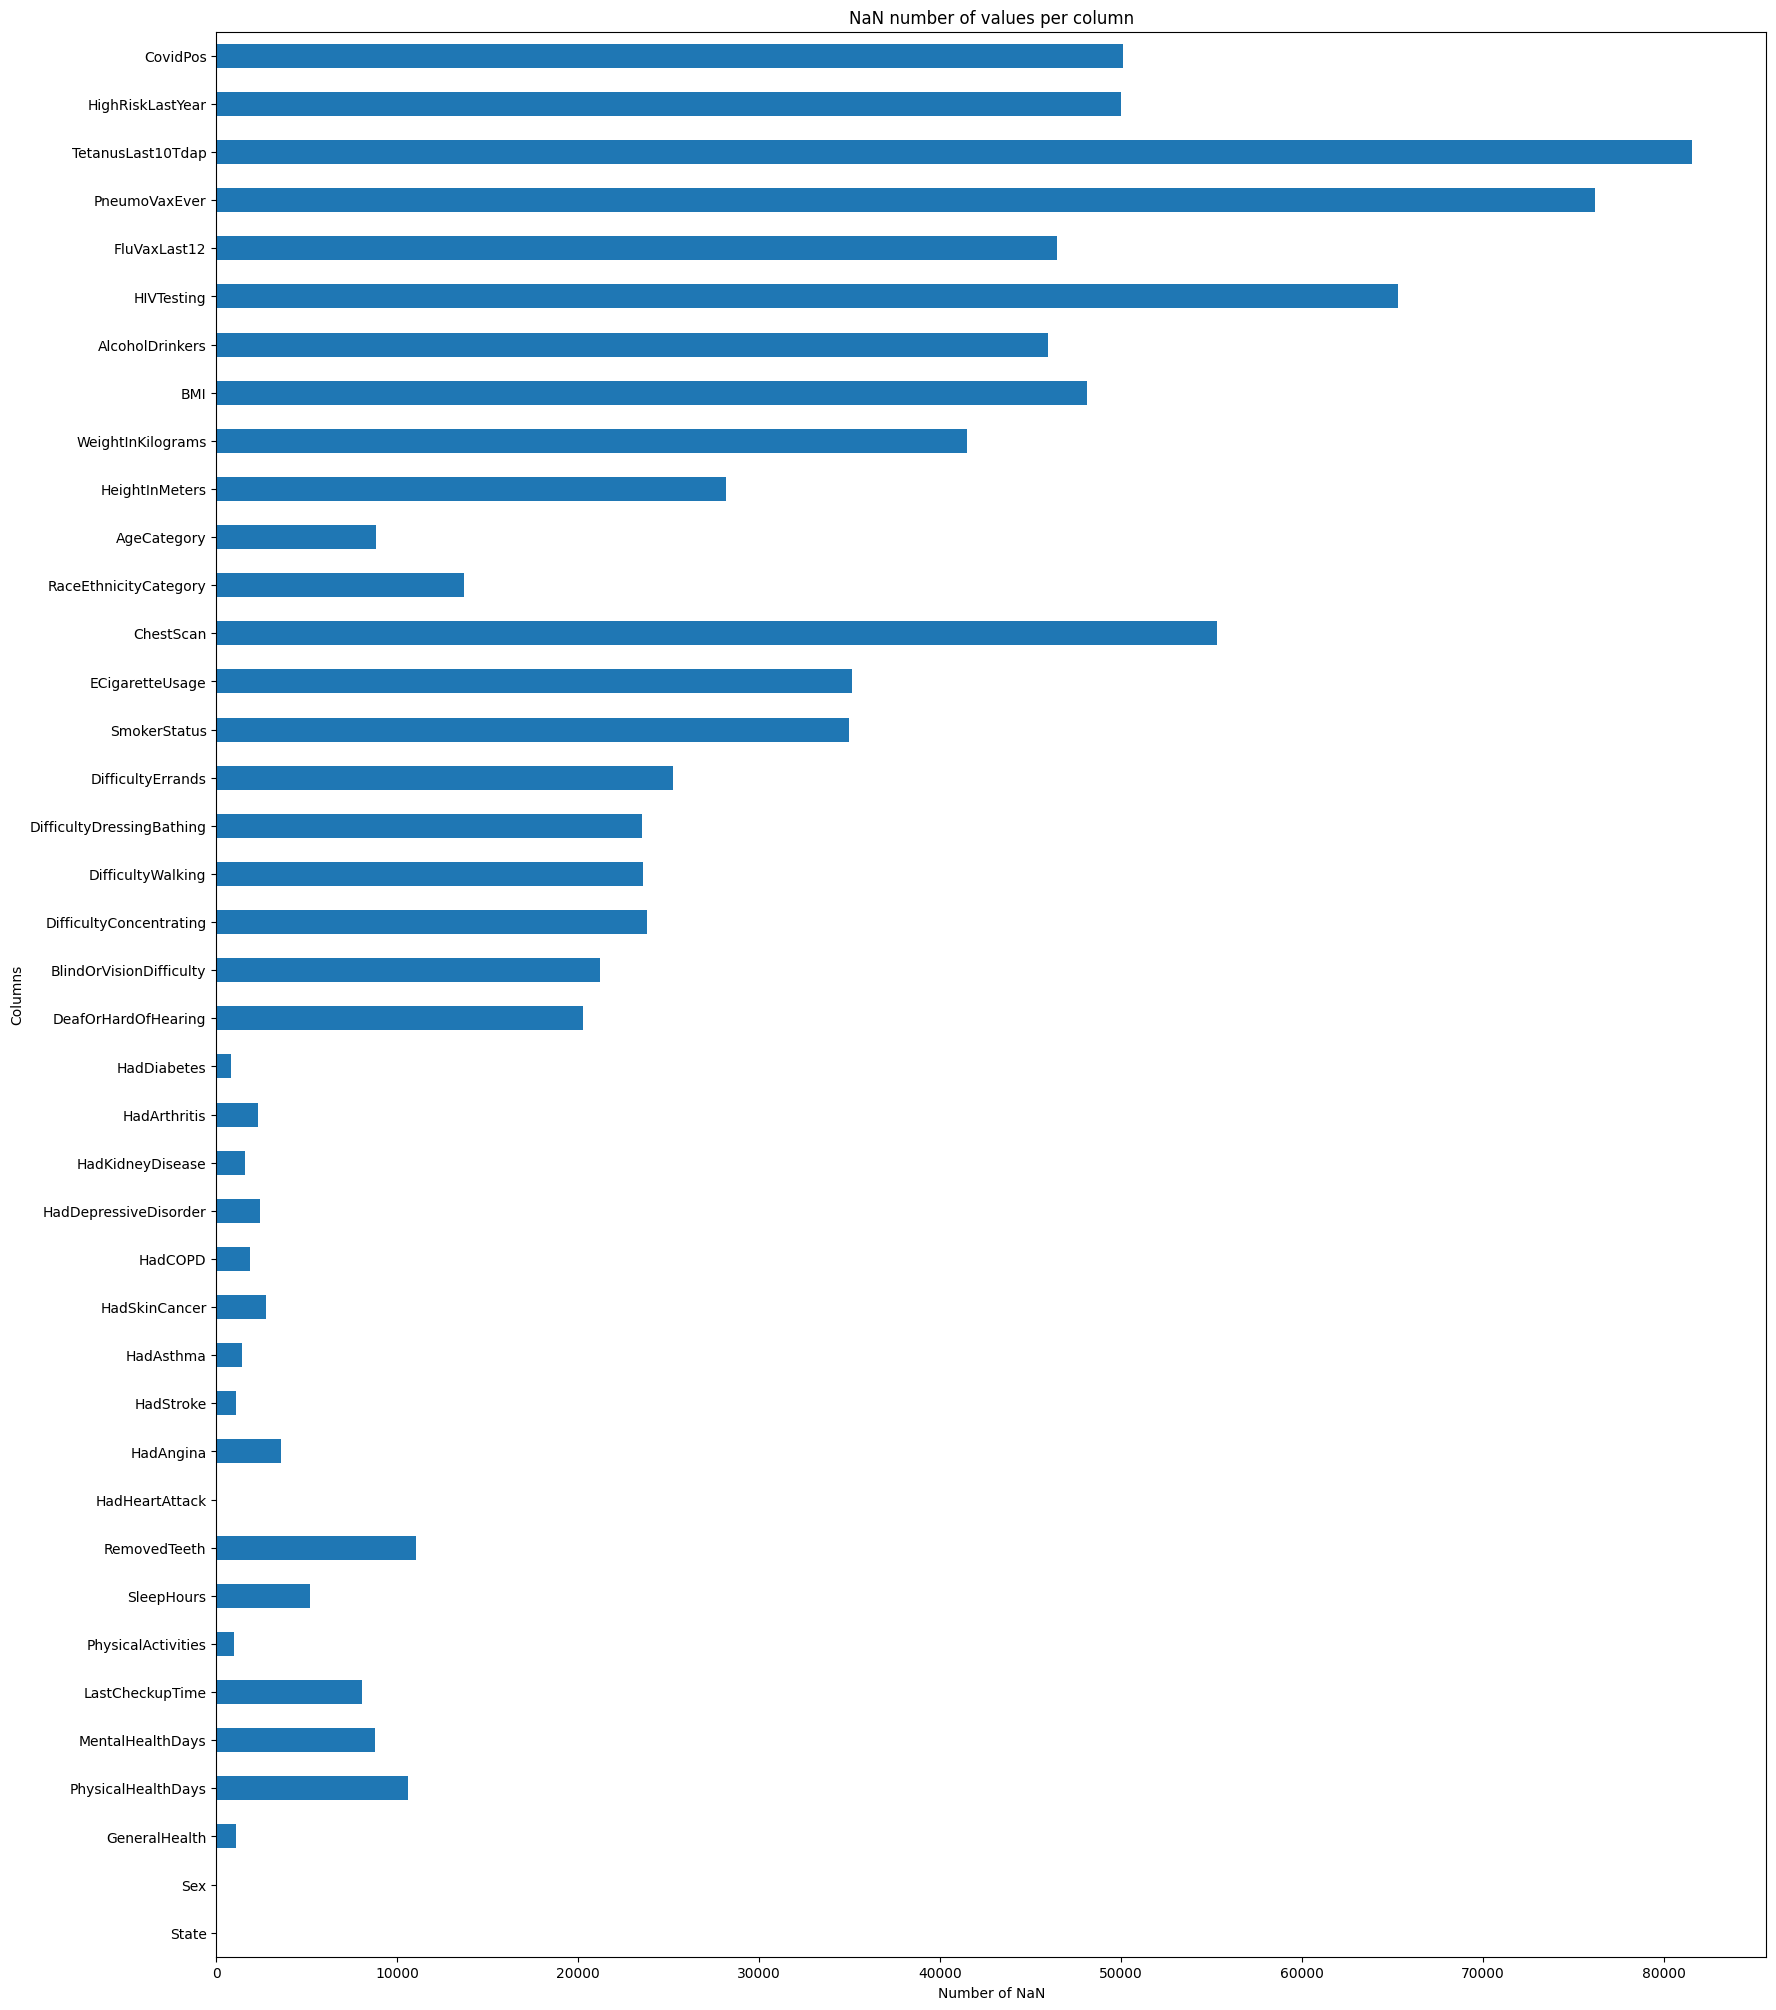

State                            0
Sex                              0
GeneralHealth                 1095
PhysicalHealthDays           10597
MentalHealthDays              8792
LastCheckupTime               8041
PhysicalActivities             972
SleepHours                    5196
RemovedTeeth                 11010
HadHeartAttack                   0
HadAngina                     3588
HadStroke                     1070
HadAsthma                     1437
HadSkinCancer                 2764
HadCOPD                       1838
HadDepressiveDisorder         2421
HadKidneyDisease              1614
HadArthritis                  2313
HadDiabetes                    813
DeafOrHardOfHearing          20278
BlindOrVisionDifficulty      21190
DifficultyConcentrating      23795
DifficultyWalking            23604
DifficultyDressingBathing    23513
DifficultyErrands            25231
SmokerStatus                 34941
ECigaretteUsage              35143
ChestScan                    55288
RaceEthnicityCategor

In [6]:

# Построим диаграмму, что проверить есть NaN значения в датасете
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 25))


nan_counts = df.isna().sum()

nan_counts.plot(kind='barh')
plt.title('NaN number of values ​​per column')
plt.ylabel('Columns')
plt.xlabel('Number of NaN')


plt.xticks(rotation=0)
plt.show()


print(nan_counts)


#Having analyzed the diagrams, we can see that there are quite a lot of NaN values ​​in the columns, and if we strangle them all, we will lose part of the dataset. In the next steps I will describe how I will deal with this situation.

In [7]:
df.shape

(442067, 40)

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [9]:
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
y_train.value_counts(normalize=True)

HadHeartAttack
No     0.943204
Yes    0.056796
Name: proportion, dtype: float64

#Now we can see that our classes are unbalanced

In [11]:
df_train=pd.concat([X_train,y_train],axis=1)
df_train.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
349425,Texas,Female,Fair,15.0,30.0,Within past year (anytime less than 12 months ...,Yes,4.0,"6 or more, but not all",No,...,48.53,17.27,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,No
149324,Maine,Male,Very good,0.0,3.0,Within past year (anytime less than 12 months ...,No,7.0,None of them,No,...,113.40,32.98,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,No
64211,Florida,Female,Poor,30.0,0.0,NaN,No,7.0,None of them,No,...,58.51,21.47,NaN,Yes,Yes,No,"Yes, received tetanus shot, but not Tdap",No,No,No
43949,Colorado,Male,Excellent,0.0,0.0,NaN,Yes,8.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
287847,Ohio,Female,Very good,5.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,1 to 5,No,...,49.90,20.12,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,No


#EDA
see at data and try to understarnd its meaning

correlation, ets

missed values -- lets remove all raws with more then N(N in our case N=5, because the percentage of people with N=5+ is only 10%) empty values | remove empty rows | remove empty columns

not balansed! -- need to handle: upsampling, downsampling, class_weights

encoding:

external sources

target encoding

remove uselss feature (?)

'Poor' (0) < 'Very good' (10) label encoding

fit(train) -> transform(test)    

In [12]:
df_train['empty_counts']=df.isnull().sum(axis=1)


In [13]:
df_train['empty_counts'].value_counts()

empty_counts
0     196660
1      69645
2      29221
3      12510
19     10430
4       5506
10      4949
8       3465
5       2956
6       2735
7       2264
20      2186
11      1736
9       1719
12      1330
13      1264
16      1117
14      1063
15      1009
18       669
21       623
17       337
22       159
23        62
24        18
25         7
26         5
27         4
29         3
28         1
Name: count, dtype: int64

In [14]:
df_train=df_train[df_train['empty_counts']<5]

In [15]:
df_train['empty_counts'].value_counts()

empty_counts
0    196660
1     69645
2     29221
3     12510
4      5506
Name: count, dtype: int64

#Now we need to analyze our data: which of them are categorical and which are numeric

In [16]:

numeric_features = df.select_dtypes(include=['int', 'float']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical signs:", numeric_features)
print("Categorical features:", categorical_features)

Numerical signs: Index(['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours',
       'HeightInMeters', 'WeightInKilograms', 'BMI'],
      dtype='object')
Categorical features: Index(['State', 'Sex', 'GeneralHealth', 'LastCheckupTime',
       'PhysicalActivities', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina',
       'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD',
       'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis',
       'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty',
       'DifficultyConcentrating', 'DifficultyWalking',
       'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus',
       'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos'],
      dtype='object')


In [17]:
for column in categorical_features:
      unique_count = df[column].nunique()
      print(f"Column '{column}' has {unique_count} unique values: {df[column].unique()}")


Column 'State' has 54 unique values: ['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina'
 'South Dakota' 'Tennessee' 'Texas' 'Utah' 'Vermont' 'Virginia'
 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']
Column 'Sex' has 2 unique values: ['Female' 'Male']
Column 'GeneralHealth' has 5 unique values: ['Very good' 'Excellent' 'Fair' 'Poor' 'Good' nan]
Column 'LastCheckupTime' has 4 unique values: ['Within past year (anytime less than 12 months ago)' nan
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within p

##It can be seen that there is a lot of categorical data in this dataset.

##I will consider each feature and convert it to numeric values.

In [18]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])

In [19]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,0,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,0,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,0,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,0,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,0,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445127,Virgin Islands,0,Good,0.0,3.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,...,1.65,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes
445128,Virgin Islands,0,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.70,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
445129,Virgin Islands,0,Poor,30.0,30.0,5 or more years ago,No,5.0,1 to 5,No,...,1.70,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
445130,Virgin Islands,1,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,5.0,None of them,Yes,...,1.83,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes


54


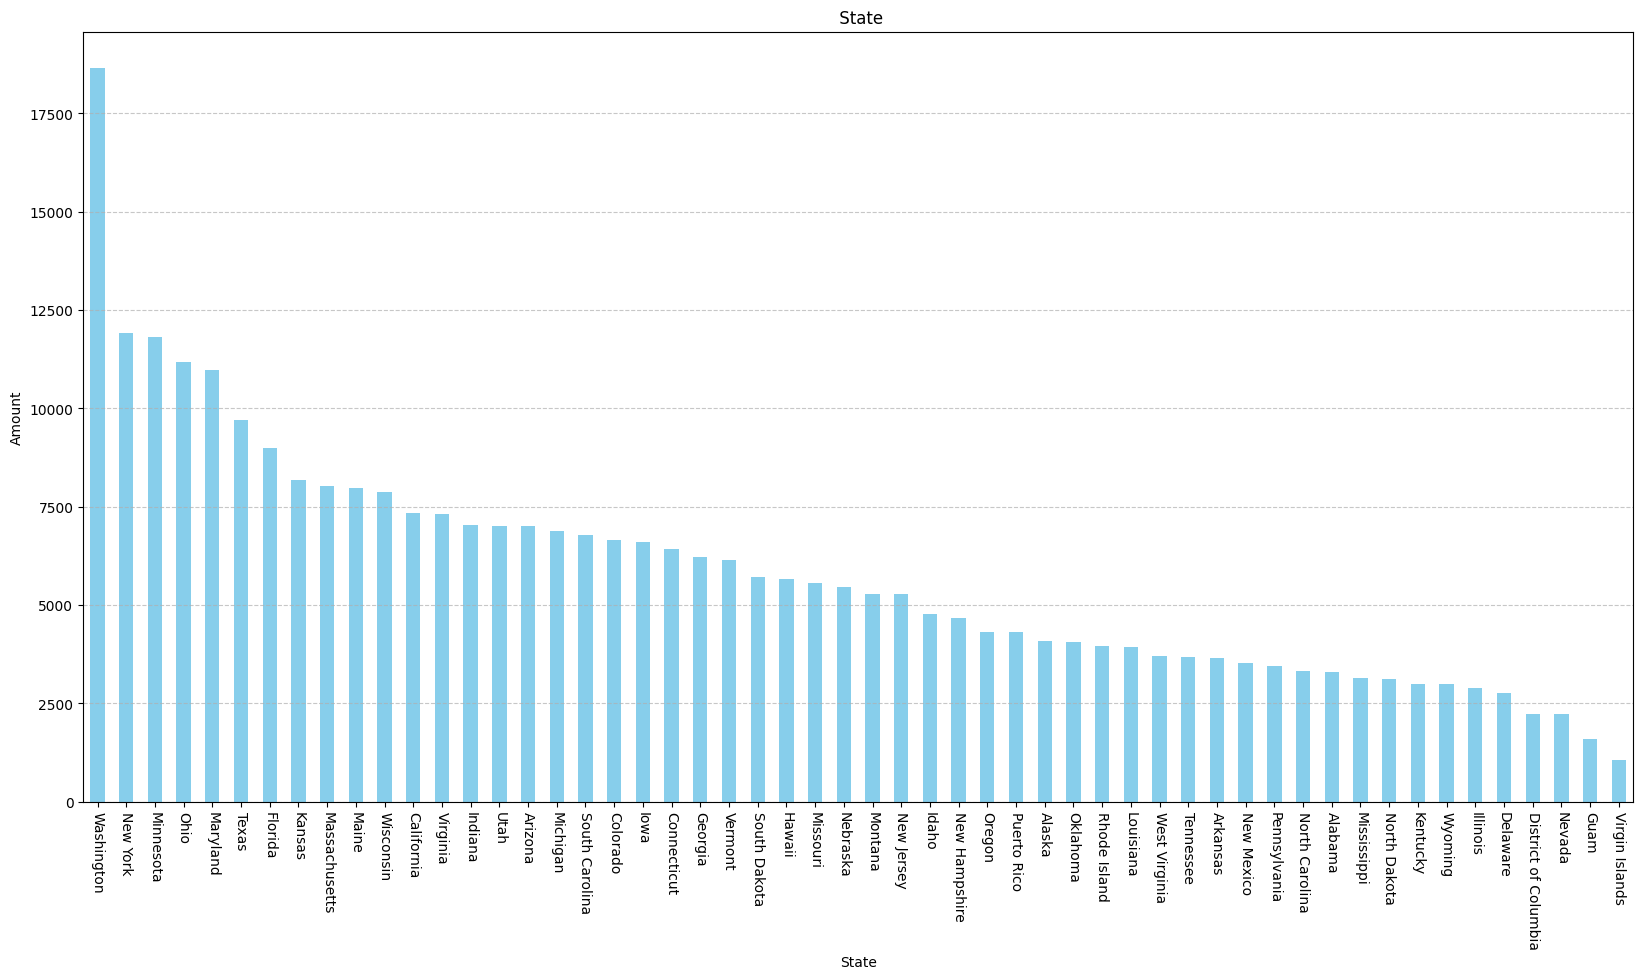

In [20]:
state_counts = df_train['State'].value_counts()
print(len(df_train['State'].unique()))
# Построение столбчатой диаграммы
plt.figure(figsize=(20, 10))
state_counts.plot(kind='bar', color='skyblue')
plt.title(' State')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##It can be seen that there are different numbers of people in State, so it would be irrational to estimate only the number of our target value in State. To do this, the following transformations will be made:

In [21]:
df['HadHeartAttack_BIN'] = df['HadHeartAttack'].map({'Yes': 1, 'No': 0})

In [22]:
agg_data_ha = df.groupby('State').agg(
    ha_count=('HadHeartAttack_BIN', 'count'),  # количество записей по каждому штату
    ha_pos=('HadHeartAttack_BIN', 'sum')  # сумма значений 'HadHeartAttack_BIN' (количество случаев с инфарктом)
).reset_index()

In [23]:
agg_data_ha['ratio']=agg_data_ha['ha_pos']/agg_data_ha['ha_count']
agg_data_ha.sort_values(by='ratio',ascending=False)
agg_data_ha['ratio_norm']=agg_data_ha['ratio']/agg_data_ha['ratio'].sum()*100
agg_data_ha.sort_values(by='ratio',ascending=False)

,State,ha_count,ha_pos,ratio,ratio_norm
51,West Virginia,4945,444,0.089788,2.891001
3,Arkansas,5241,454,0.086625,2.789159
9,Florida,13282,1018,0.076645,2.467833
30,New Hampshire,6706,500,0.074560,2.400701
37,Oklahoma,5707,412,0.072192,2.324454
18,Kentucky,4004,289,0.072178,2.323996
44,Tennessee,5234,371,0.070883,2.282295
20,Maine,10584,750,0.070862,2.281618
2,Arizona,10089,708,0.070175,2.259523
0,Alabama,4475,312,0.069721,2.244880


In [24]:
df= pd.merge(df, agg_data_ha[['State', 'ratio_norm']], on='State', how='left')

In [25]:
df['State']=df['ratio_norm']
df = df.drop('ratio_norm', axis=1)

In [26]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,Good,0.0,3.0,Within past 2 years (1 year but less than 2 ye...,Yes,6.0,None of them,No,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,Excellent,2.0,2.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,Poor,30.0,30.0,5 or more years ago,No,5.0,1 to 5,No,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,5.0,None of them,Yes,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


## Now about GeneralHealth

6


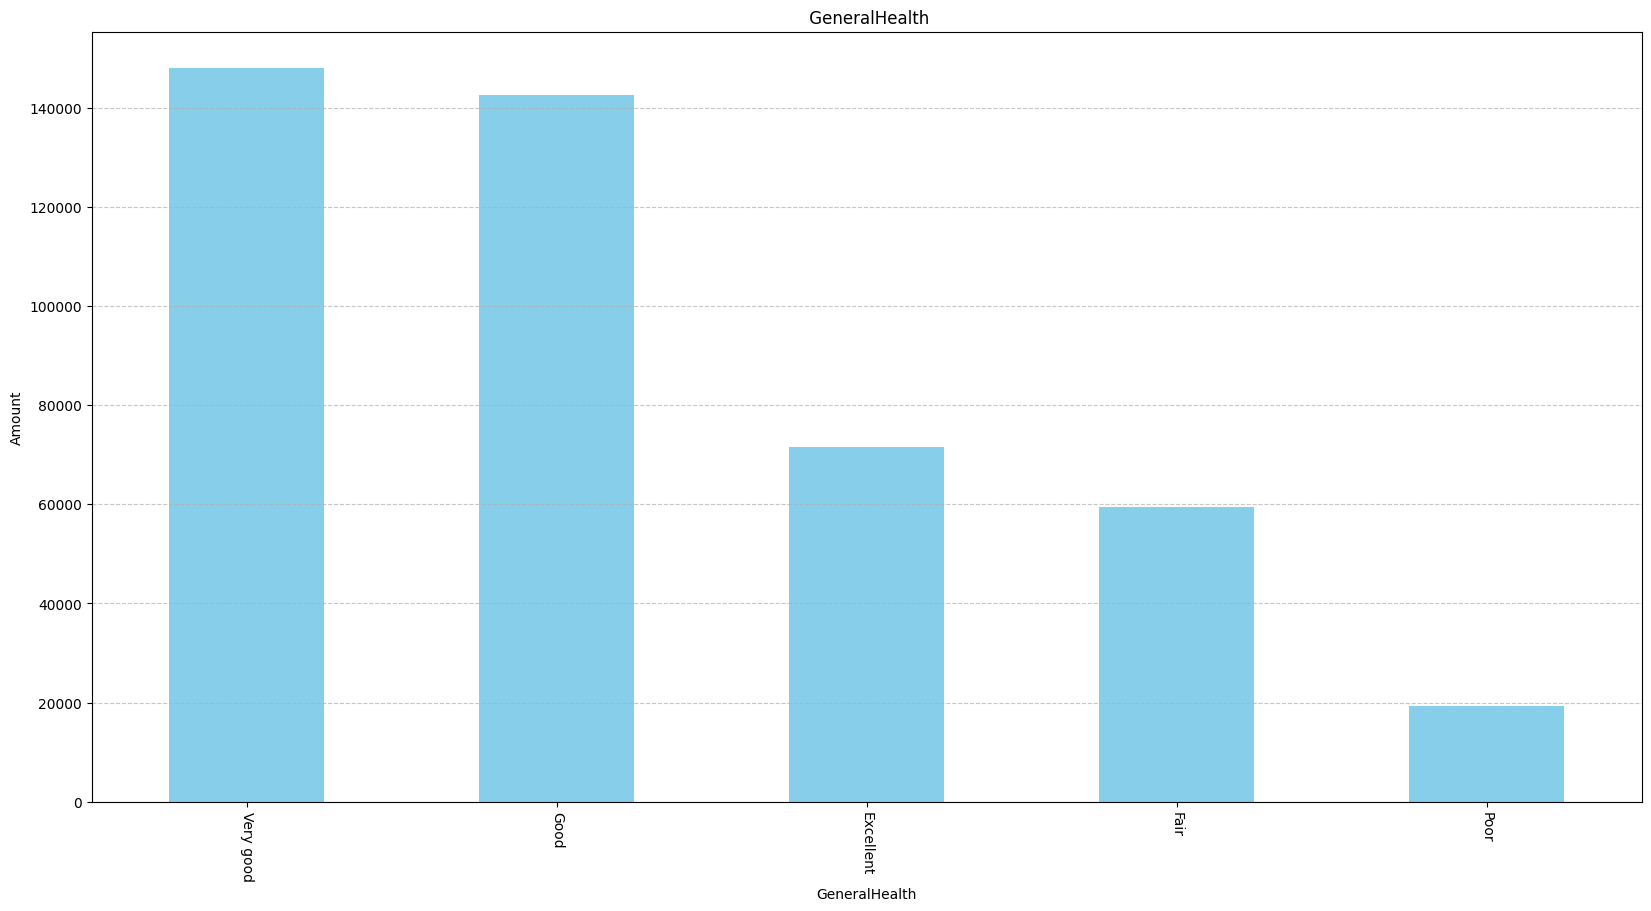

In [27]:


GeneralHealth = df['GeneralHealth'].value_counts()
print(len(df['GeneralHealth'].unique()))

plt.figure(figsize=(20, 10))
GeneralHealth.plot(kind='bar', color='skyblue')
plt.title(' GeneralHealth')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [28]:
an_count = df['GeneralHealth'].isna().sum()
print(an_count)


1095


##I will fill Nan values ​​with the average value - Good

In [29]:
df['GeneralHealth'] = df['GeneralHealth'].fillna('Good')

In [30]:
an_count = df['GeneralHealth'].isna().sum()
print(an_count)


0


In [31]:
priorities = {'Very good': 4, 'Good': 3, 'Excellent': 5,'Fair':2,'Poor':1}
label_encoder = LabelEncoder()
df['GeneralHealth'] = df['GeneralHealth'].map(lambda x: priorities[x])

##And now about LastCheckupTime

5


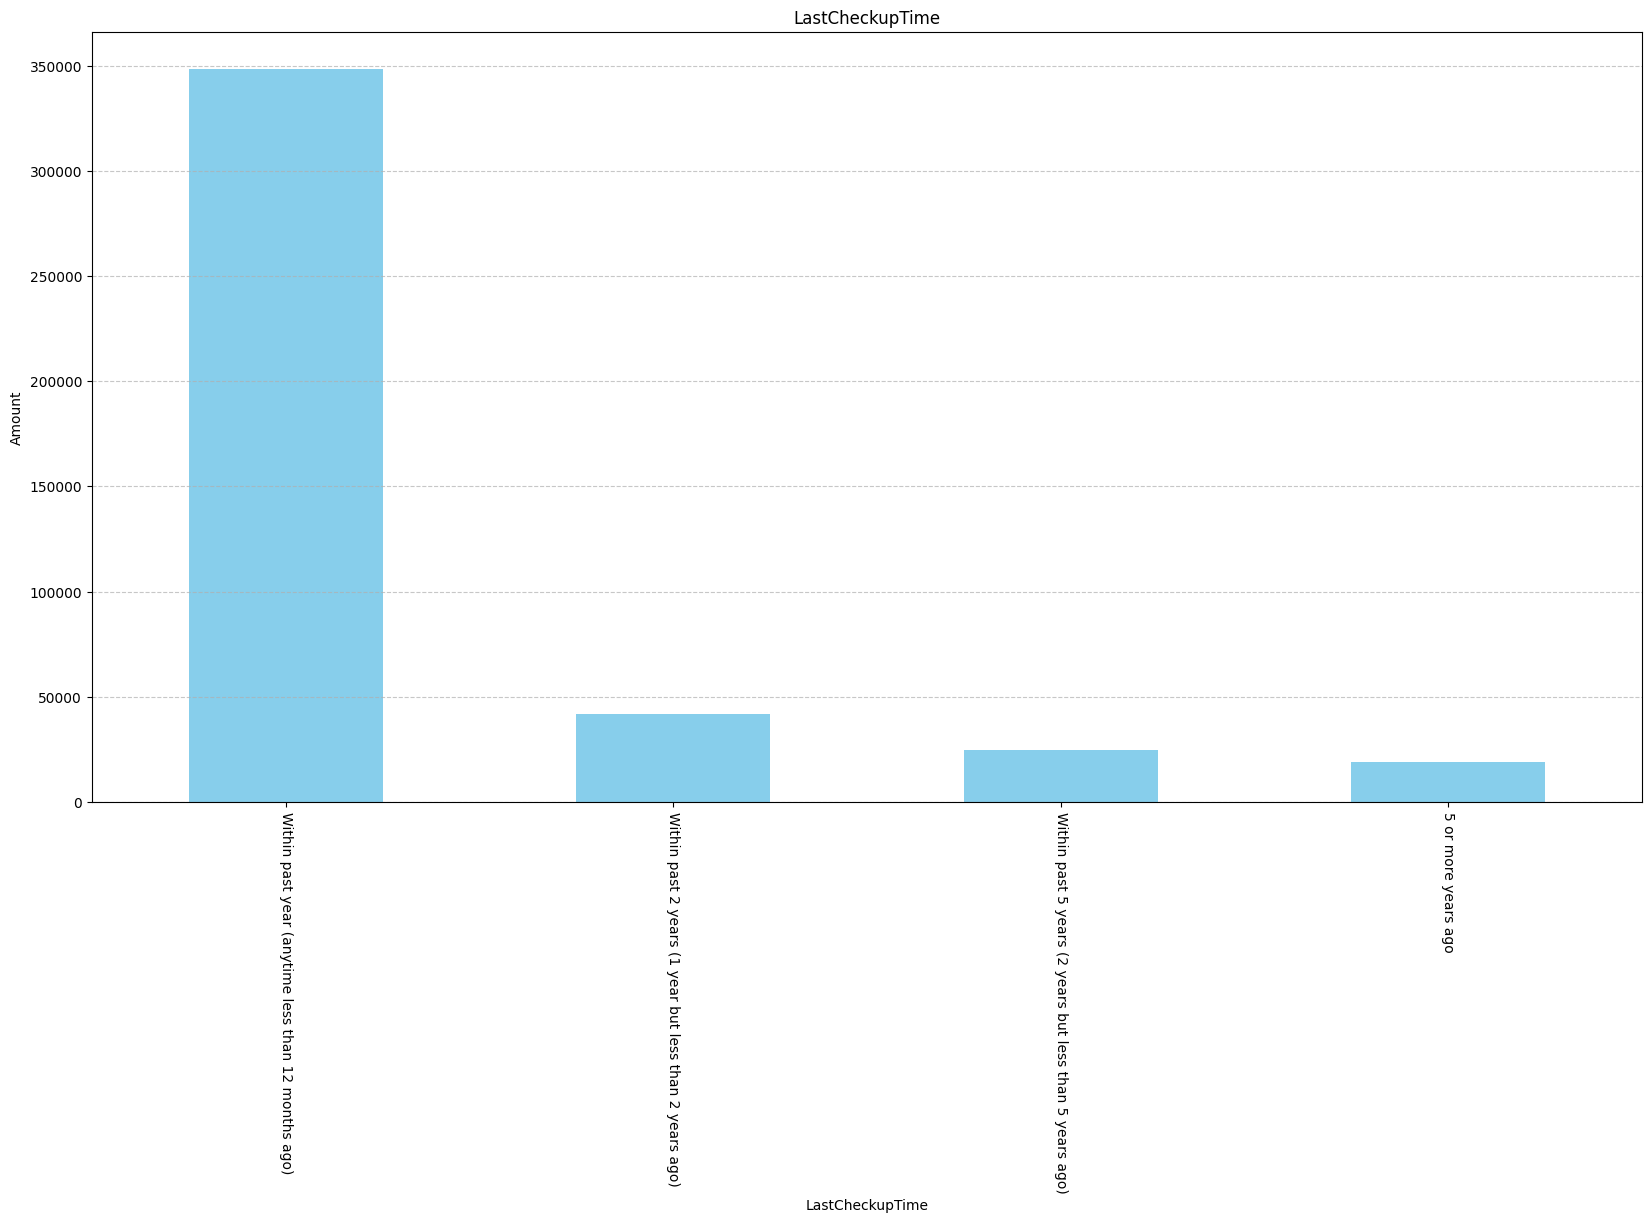

In [32]:

LastCheckupTime = df['LastCheckupTime'].value_counts()
print(len(df['LastCheckupTime'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('LastCheckupTime')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [33]:
# Изучив график можно сделать вывод, что 4 времени  можно разделить на 3 группы приоритета.
# поэтому для LastCheckupTime буду использовать LabelEncoder. В дальнейшем подразумеваются похожего рода рассуждения, которые обоснованы показателями графиков

df['LastCheckupTime'] = df['LastCheckupTime'].fillna('Within past 2 years (1 year but less than 2 years ago)')


priorities = {'Within past year (anytime less than 12 months ago)': 3, 'Within past 2 years (1 year but less than 2 years ago)': 2, 'Within past 5 years (2 years but less than 5 years ago)': 1,'5 or more years ago':1}

# Применение Label Encoding с учетом приоритетов
label_encoder = LabelEncoder()
'''
['Within past year (anytime less than 12 months ago)' nan
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within past 5 years (2 years but less than 5 years ago)'
 '5 or more years ago']
 '''


df['LastCheckupTime'] = df['LastCheckupTime'].map(lambda x: priorities[x])

##And now about PhysicalActivities

3


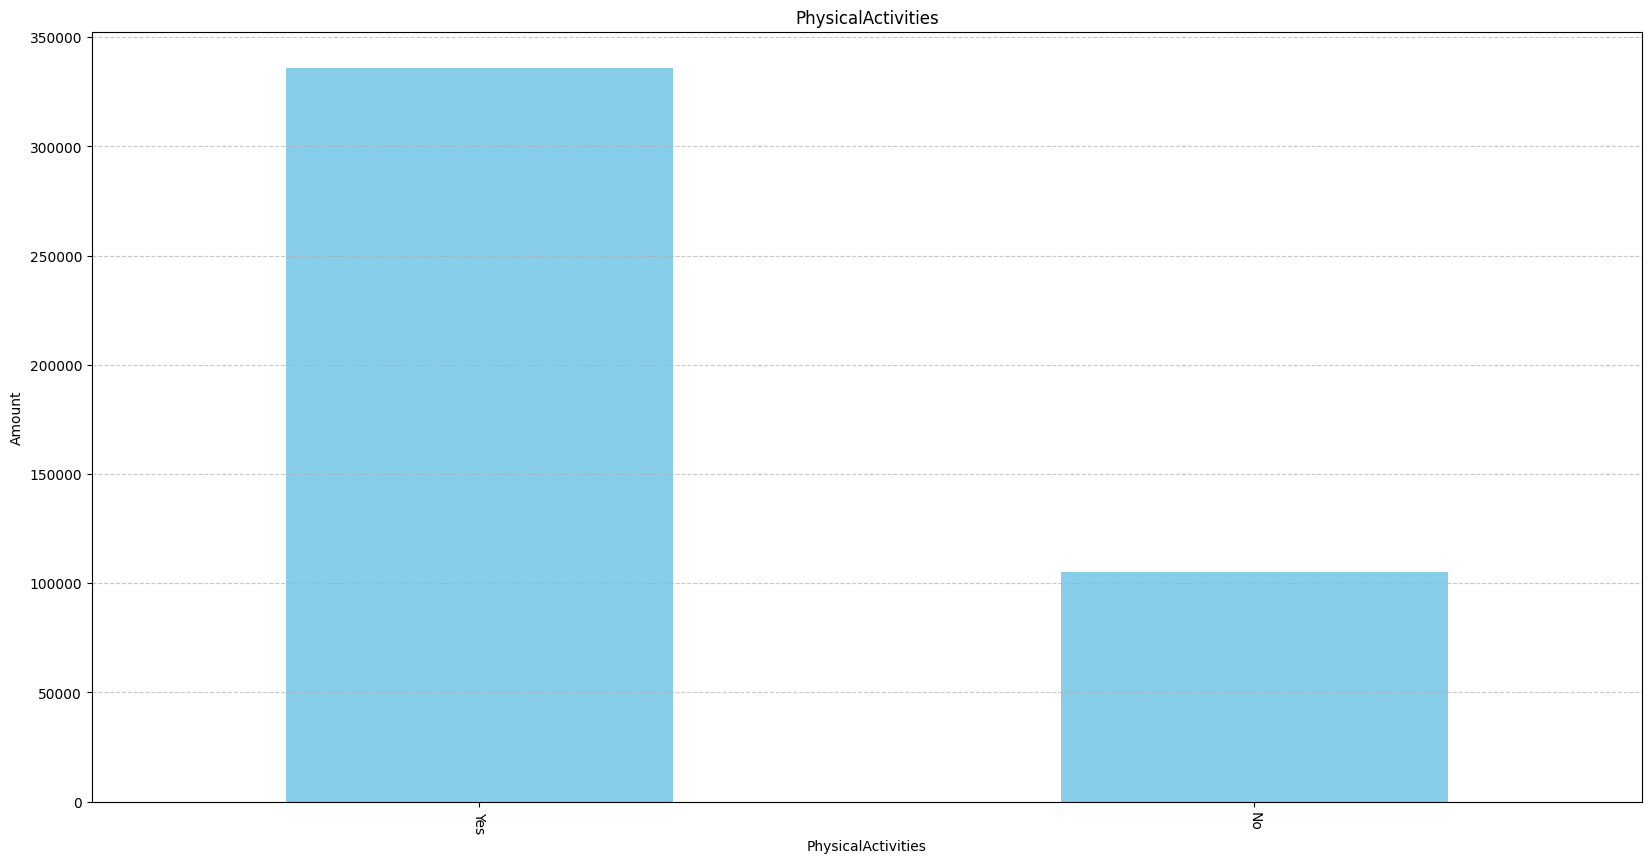

In [34]:

LastCheckupTime = df['PhysicalActivities'].value_counts()
print(len(df['PhysicalActivities'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('PhysicalActivities')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [35]:
Nan_count = df['PhysicalActivities'].isna().sum()
print(Nan_count)

df['PhysicalActivities'] = label_encoder.fit_transform(df['PhysicalActivities'])

972


In [36]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,NaN,No,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,NaN,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,NaN,No,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,NaN,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,NaN,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,None of them,No,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,None of them,No,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,1 to 5,No,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,None of them,Yes,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


##And now about RemovedTeeth

5


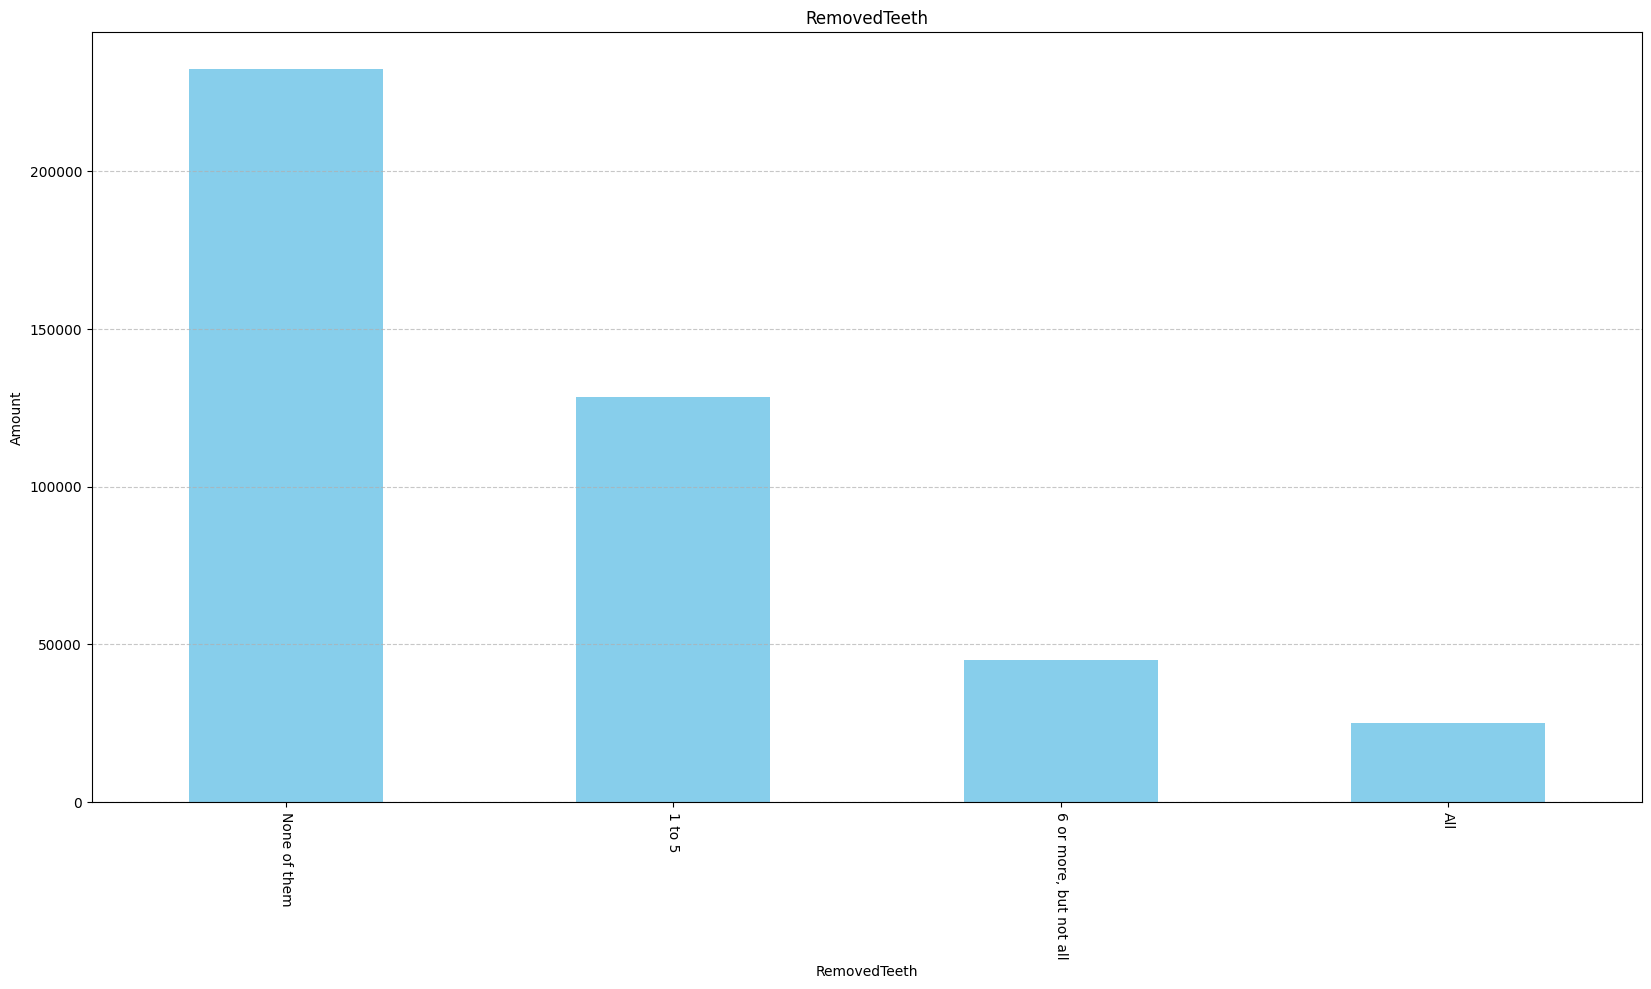

In [37]:

LastCheckupTime = df['RemovedTeeth'].value_counts()
print(len(df['RemovedTeeth'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('RemovedTeeth')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [38]:

priorities = {'None of them': 3, '1 to 5': 2, '6 or more, but not all': 1,'All':0}
label_encoder = LabelEncoder()
df['RemovedTeeth'] = df['RemovedTeeth'].fillna('1 to 5')

df['RemovedTeeth'] = df['RemovedTeeth'].map(lambda x: priorities[x])

In [39]:
df.drop('HadHeartAttack', axis=1, inplace=True)

In [40]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,2,No,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,2,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,2,No,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,2,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,2,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,3,No,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,3,No,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,2,No,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,3,No,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


##And now about HadAngina

In [41]:
df['HadAngina'] = label_encoder.fit_transform(df['HadAngina'])

In [42]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,2,0,...,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,2,0,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,2,0,...,63.50,25.61,No,No,No,No,NaN,No,Yes,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,2,0,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,2,0,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,3,0,...,69.85,25.63,NaN,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,Yes,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,3,0,...,83.01,28.66,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,2,0,...,49.90,17.23,NaN,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,3,0,...,108.86,32.55,No,Yes,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes,1


In [43]:
df['HadAngina'] = label_encoder.fit_transform(df['HadAngina'])

In [44]:
# Список столбцов, которые нужно закодировать
columns_to_encode = ['HadStroke', 'HadAsthma', 'HadSkinCancer','HadCOPD','HadDepressiveDisorder','HadKidneyDisease','HadArthritis','DeafOrHardOfHearing','BlindOrVisionDifficulty','DifficultyConcentrating','DifficultyWalking','DifficultyDressingBathing','DifficultyErrands','ChestScan','AlcoholDrinkers','HIVTesting','FluVaxLast12','PneumoVaxEver','HighRiskLastYear']


label_encoder = LabelEncoder()
df[columns_to_encode] = df[columns_to_encode].apply(lambda col: label_encoder.fit_transform(col))


##And now about HadDiabetes

5


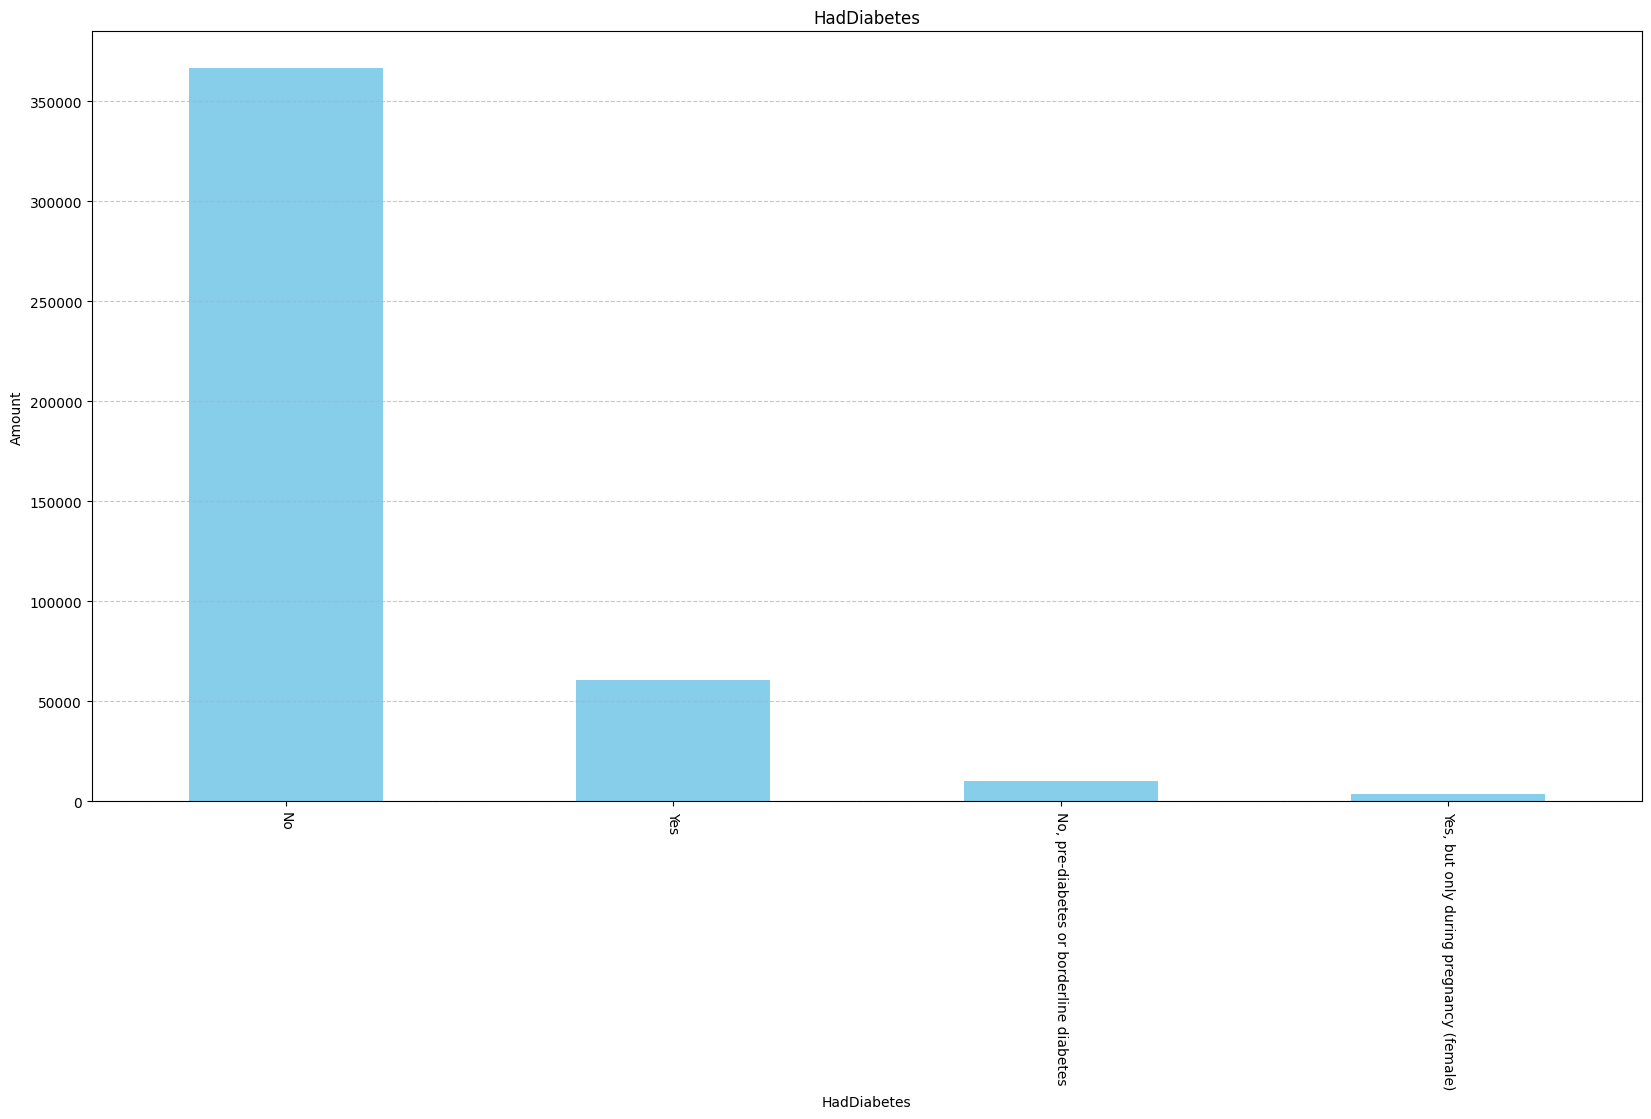

In [45]:

LastCheckupTime = df['HadDiabetes'].value_counts()
print(len(df['HadDiabetes'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('HadDiabetes')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [46]:

priorities = {'Yes': 1, 'No': 0, 'No, pre-diabetes or borderline diabetes': 0.5,'Yes, but only during pregnancy (female)':0}
label_encoder = LabelEncoder()
df['HadDiabetes'] = df['HadDiabetes'].fillna('No')

df['HadDiabetes'] = df['HadDiabetes'].map(lambda x: priorities[x])

5


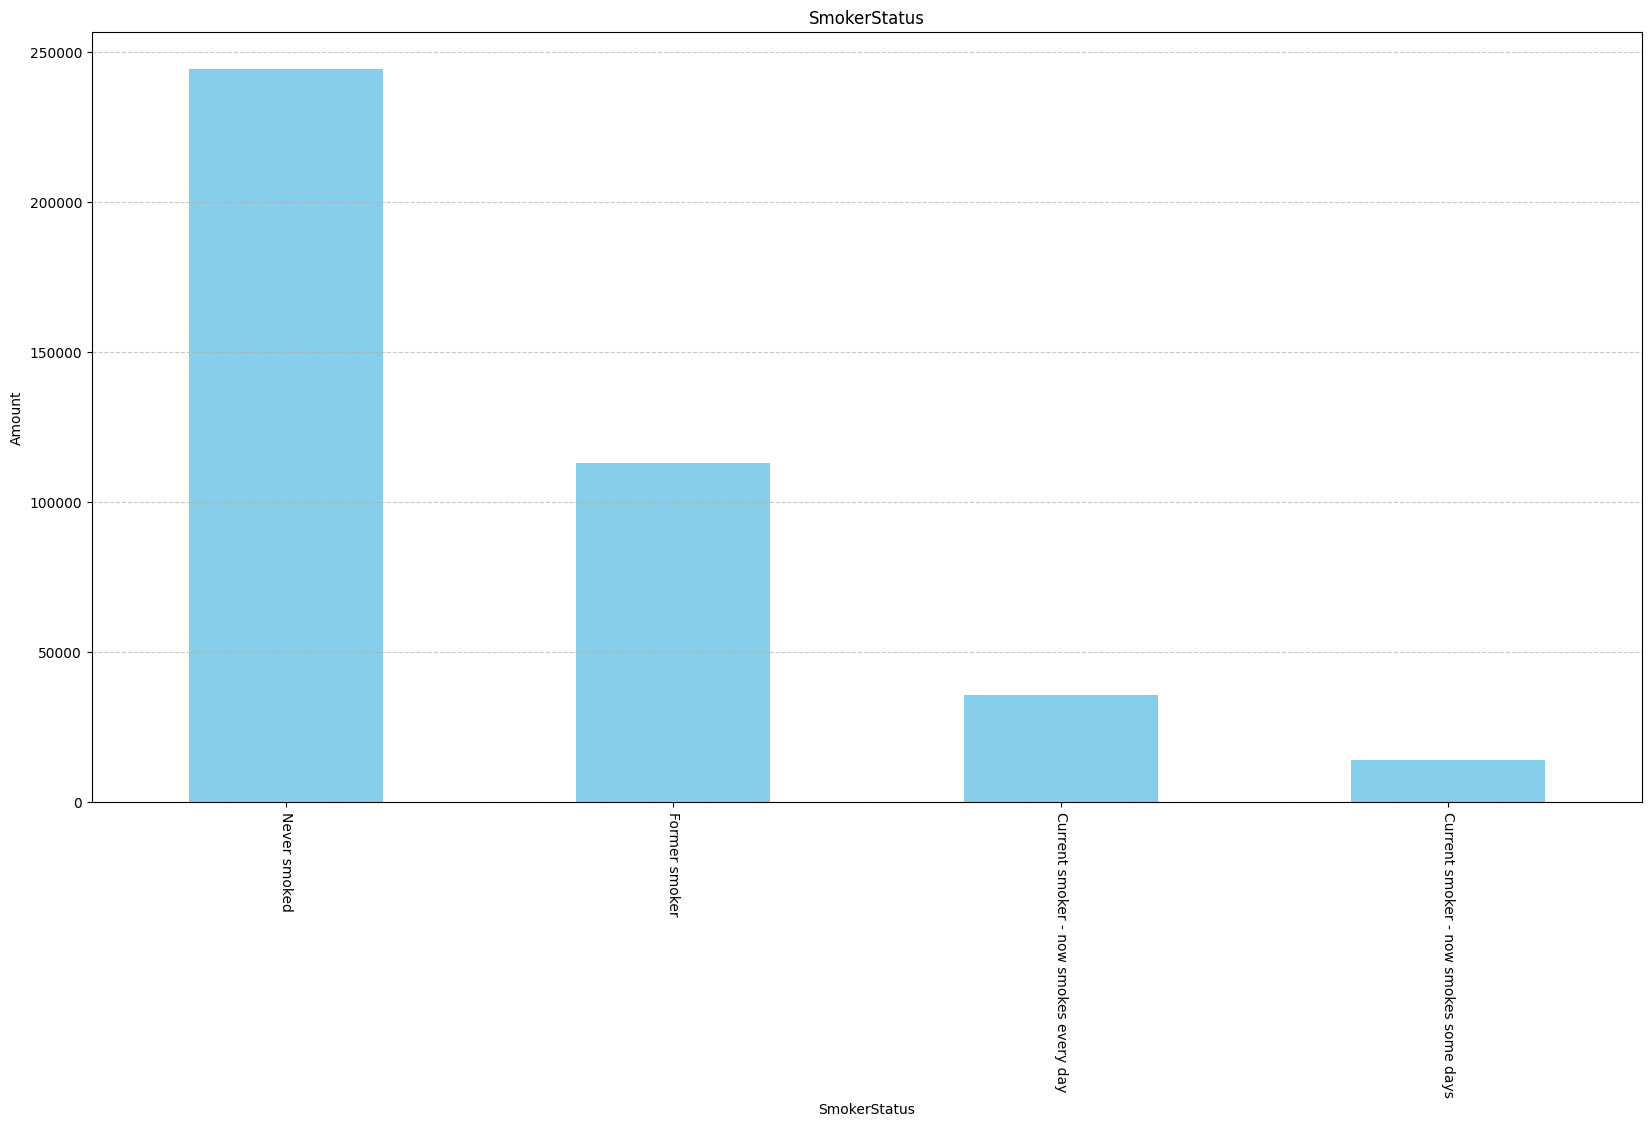

In [47]:

LastCheckupTime = df['SmokerStatus'].value_counts()
print(len(df['SmokerStatus'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('SmokerStatus')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [49]:
df['SmokerStatus'] = df['SmokerStatus'].fillna('Never smoked')


priorities = {'Never smoked': 3, 'Former smoker': 2, 'Current smoker - now smokes some days': 1,'Current smoker - now smokes every day':0.5}


label_encoder = LabelEncoder()


df['SmokerStatus'] = df['SmokerStatus'].map(lambda x: priorities[x])


In [51]:
df['SmokerStatus']

0         3.0
1         3.0
2         3.0
3         1.0
4         3.0
         ... 
442062    3.0
442063    3.0
442064    0.5
442065    3.0
442066    2.0
Name: SmokerStatus, Length: 442067, dtype: float64

5


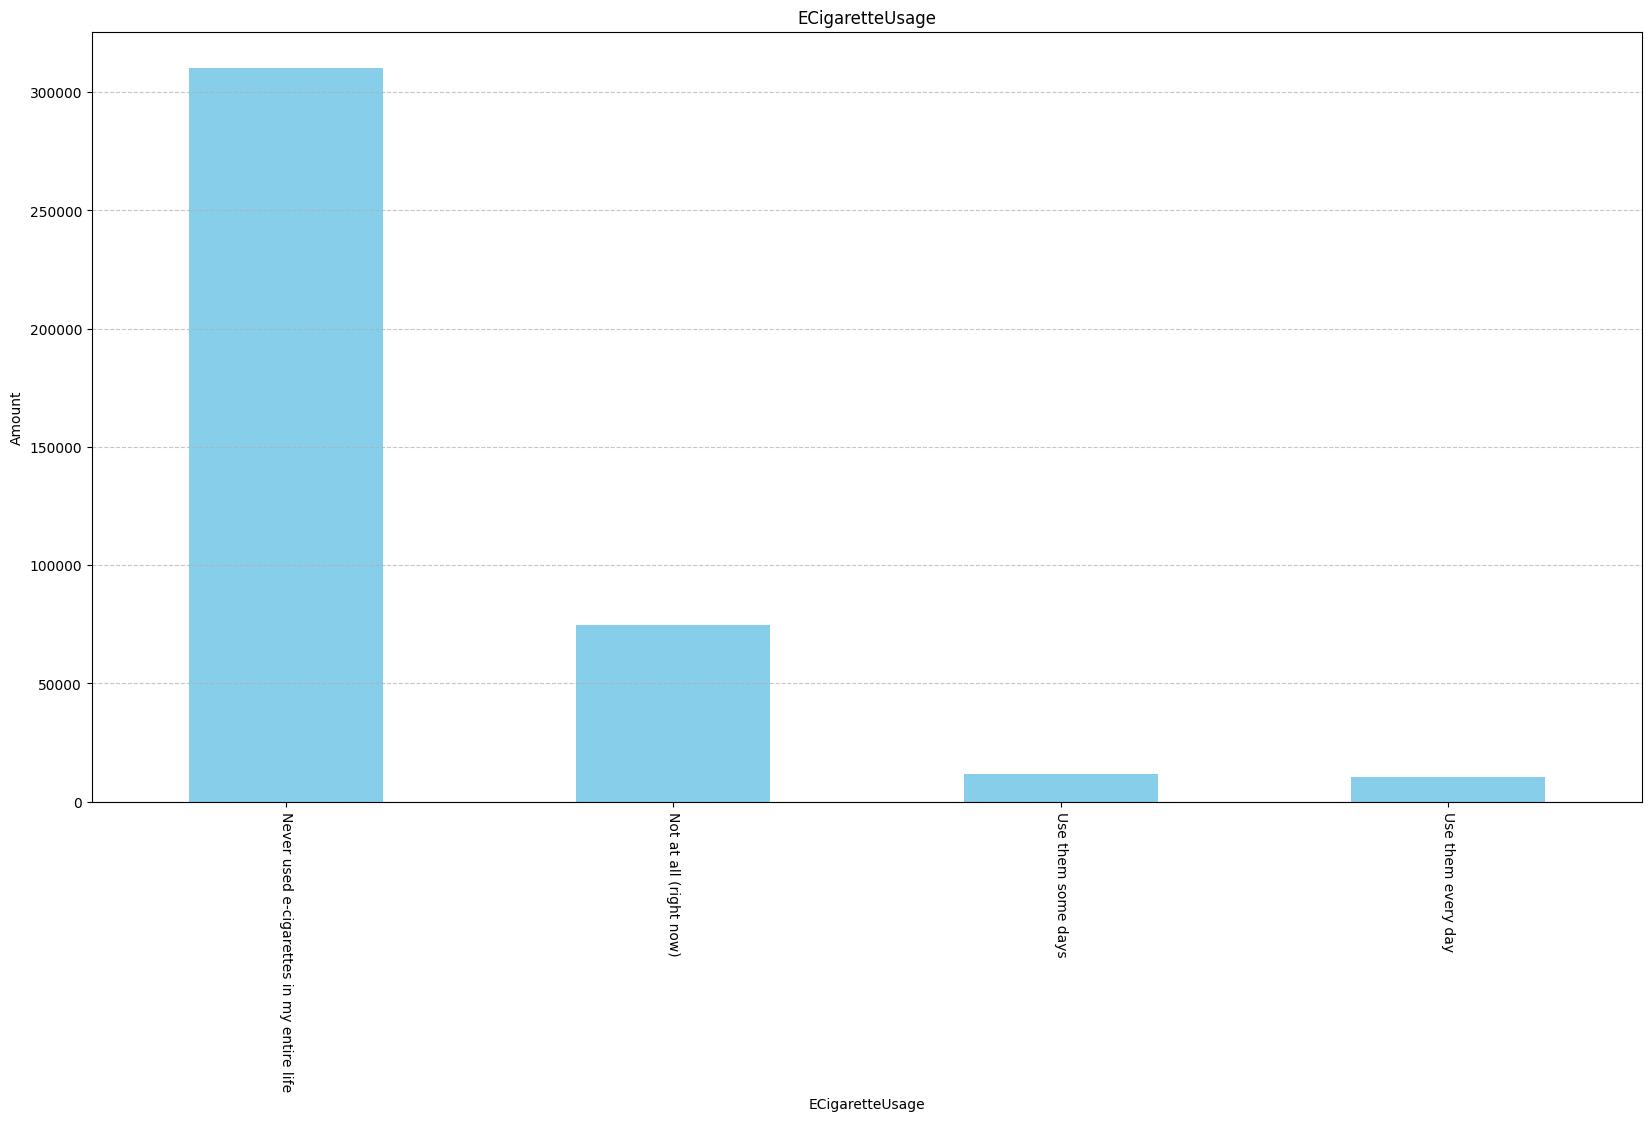

In [52]:

LastCheckupTime = df['ECigaretteUsage'].value_counts()
print(len(df['ECigaretteUsage'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('ECigaretteUsage')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [53]:
df['ECigaretteUsage'] = df['ECigaretteUsage'].fillna('Never used e-cigarettes in my entire life')


priorities = {'Never used e-cigarettes in my entire life': 3, 'Not at all (right now)': 2, 'Use them every day': 1,'Use them some days':1}


label_encoder = LabelEncoder()


df['ECigaretteUsage'] = df['ECigaretteUsage'].map(lambda x: priorities[x])


6


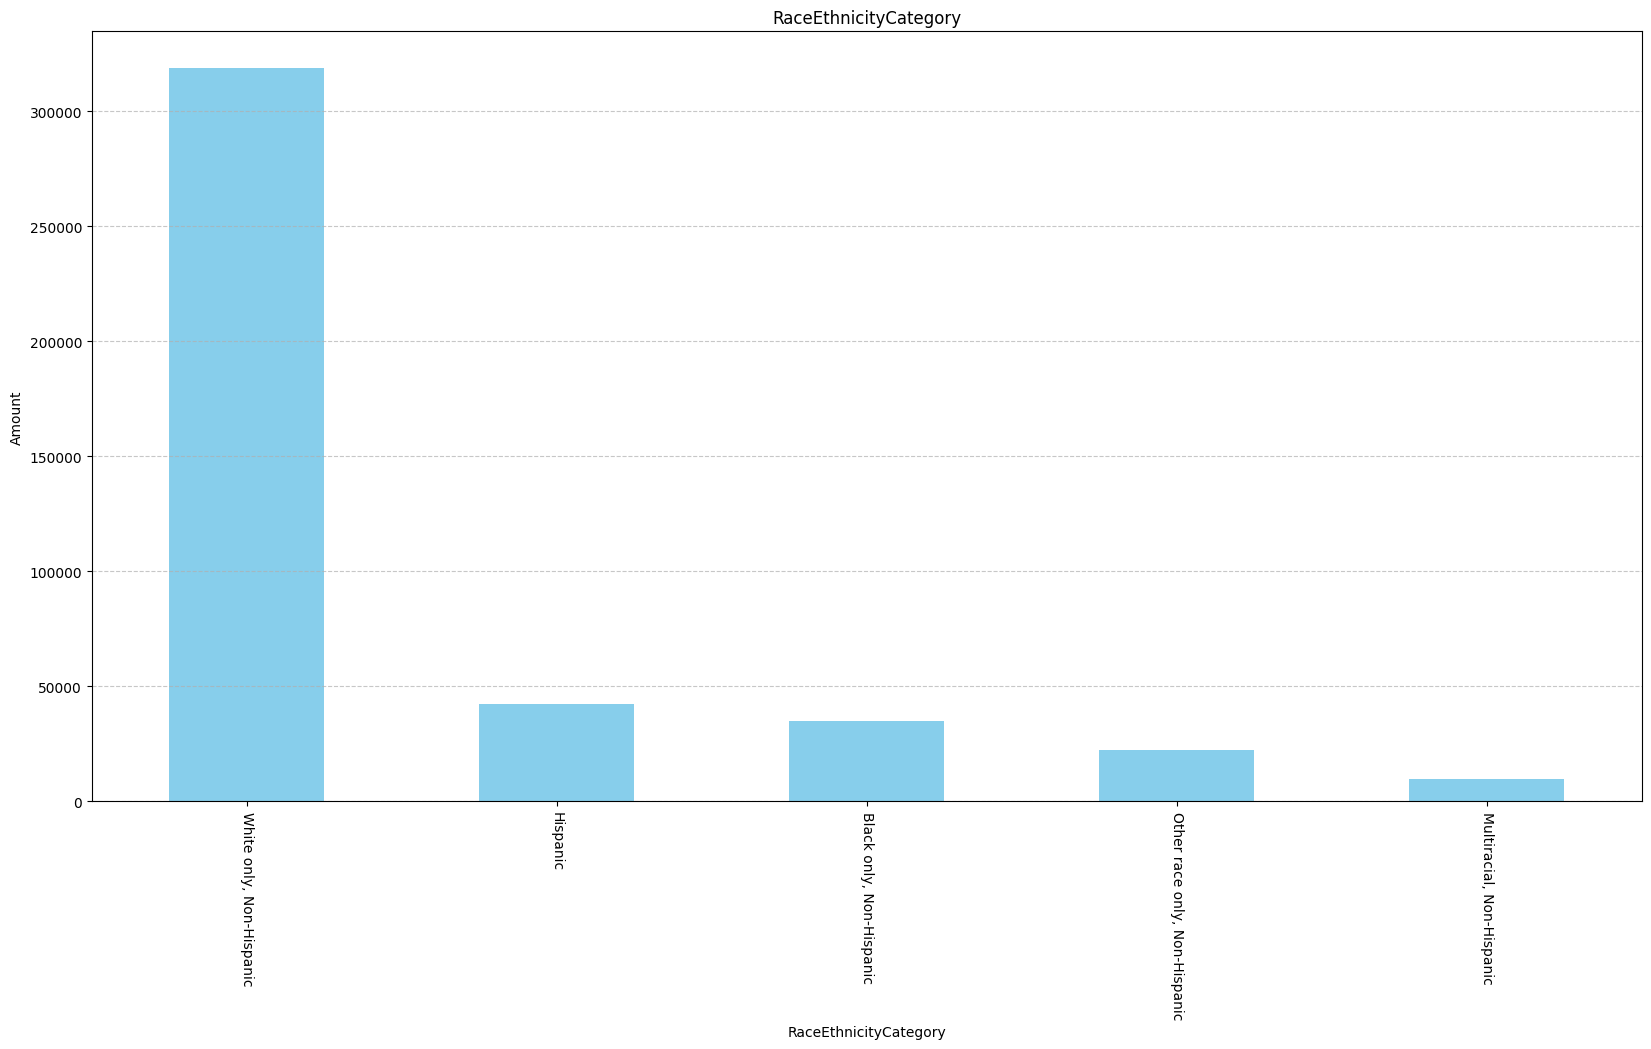

In [54]:

LastCheckupTime = df['RaceEthnicityCategory'].value_counts()
print(len(df['RaceEthnicityCategory'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('RaceEthnicityCategory')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [55]:
df['RaceEthnicityCategory'] = df['RaceEthnicityCategory'].fillna('White only, Non-Hispanic')

df['RaceEthnicityCategory'] = label_encoder.fit_transform(df['RaceEthnicityCategory'])


14


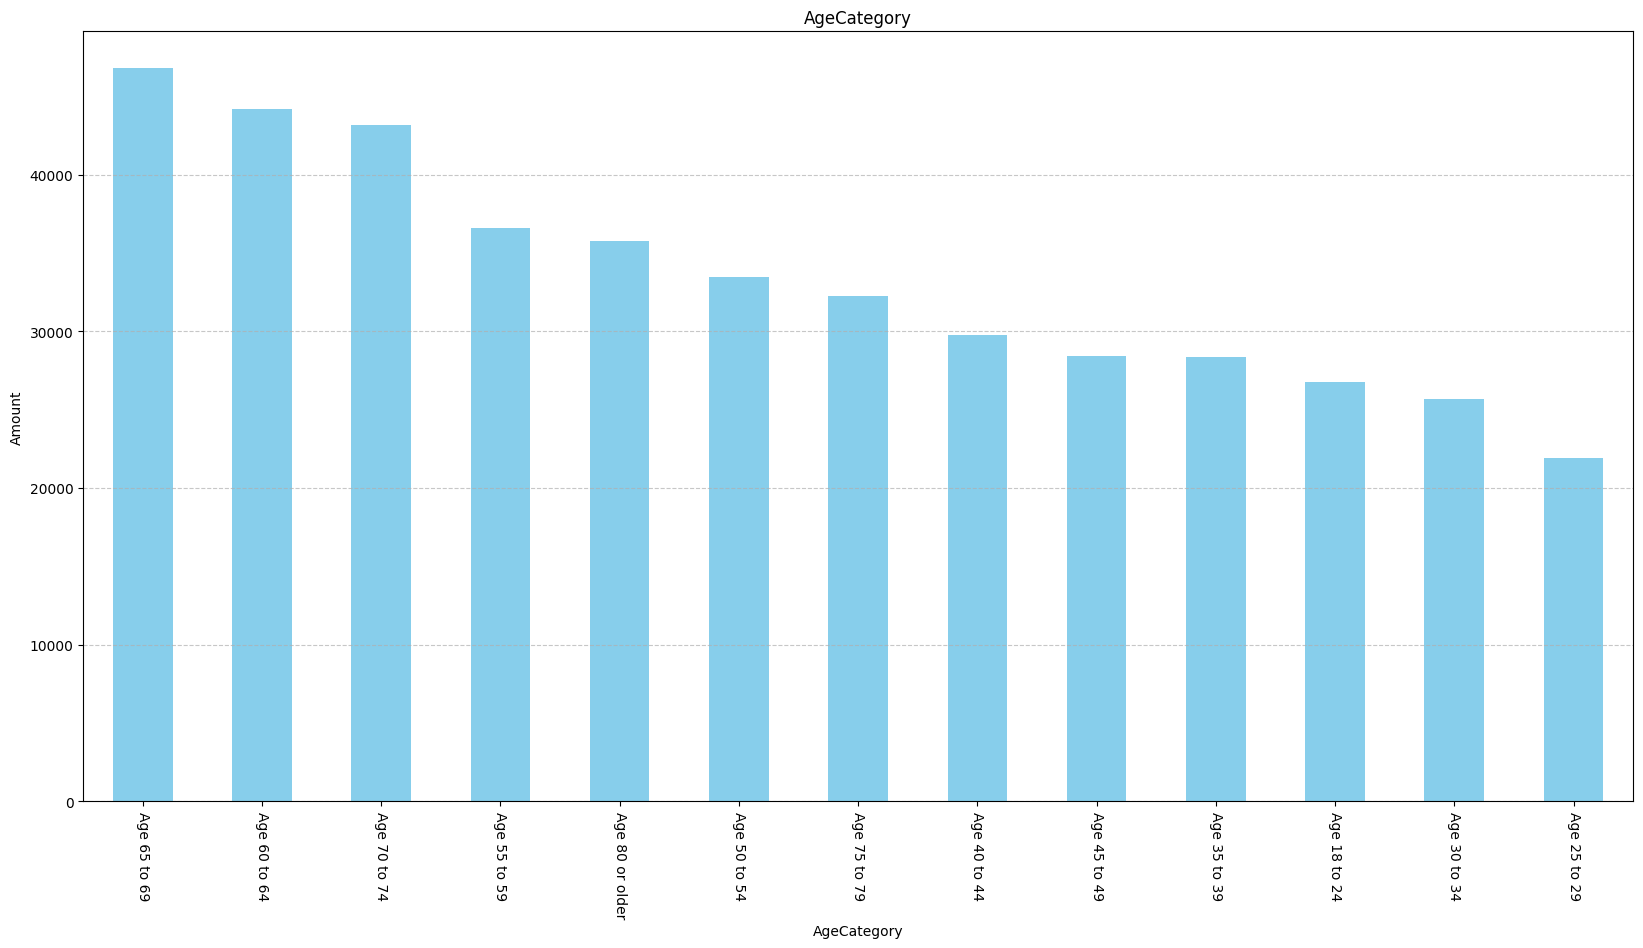

In [56]:

LastCheckupTime = df['AgeCategory'].value_counts()
print(len(df['AgeCategory'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('AgeCategory')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [63]:
df['AgeCategory'] = label_encoder.fit_transform(df['AgeCategory'])

5


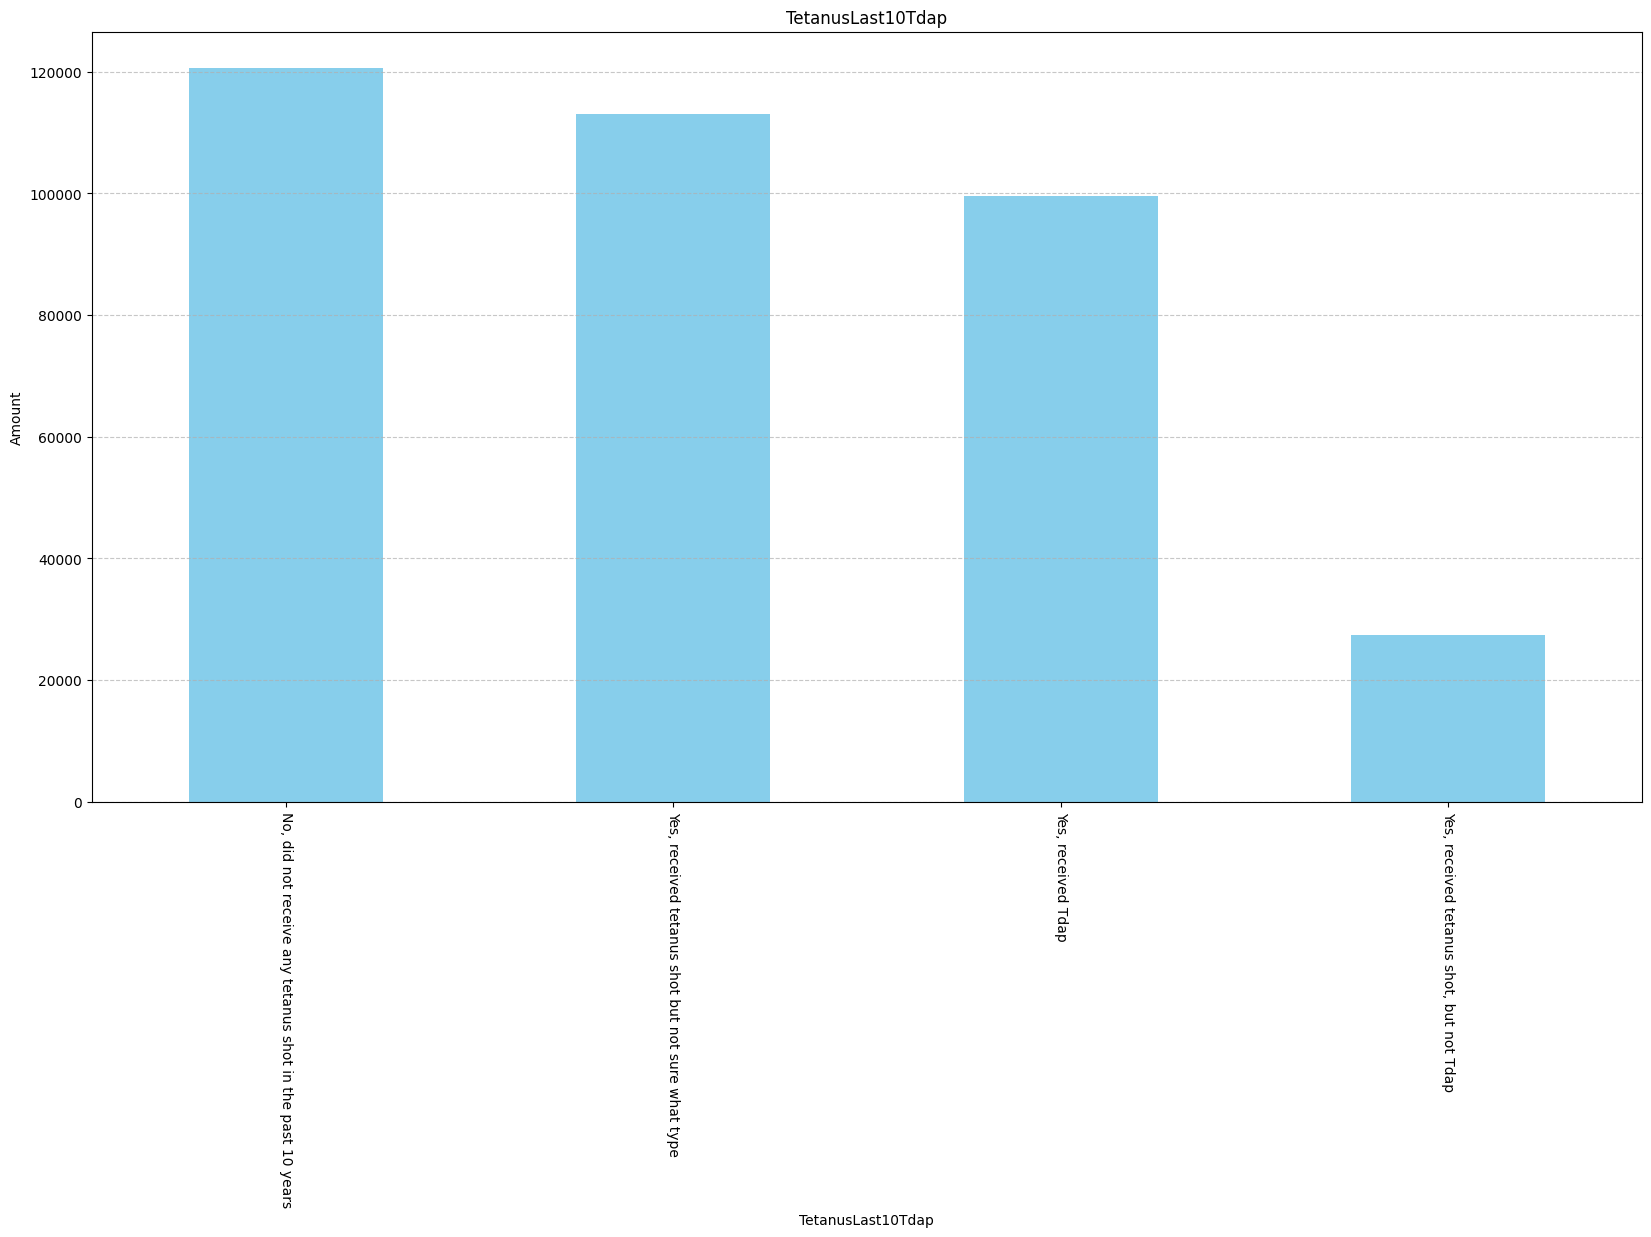

In [57]:

LastCheckupTime = df['TetanusLast10Tdap'].value_counts()
print(len(df['TetanusLast10Tdap'].unique()))

plt.figure(figsize=(20, 10))
LastCheckupTime.plot(kind='bar', color='skyblue')
plt.title('TetanusLast10Tdap')

plt.ylabel('Amount')
plt.xticks(rotation=-90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [58]:
df['TetanusLast10Tdap'] = df['TetanusLast10Tdap'].fillna('No, did not receive any tetanus shot in the past 10 years')


priorities = {'No, did not receive any tetanus shot in the past 10 years': 4, 'Yes, received tetanus shot but not sure what type': 3,
              'Yes, received Tdap': 2,'Yes, received tetanus shot, but not Tdap':1}


label_encoder = LabelEncoder()


df['TetanusLast10Tdap'] = df['TetanusLast10Tdap'].map(lambda x: priorities[x])


In [59]:
df['CovidPos'] = label_encoder.fit_transform(df['CovidPos'])

In [60]:
df

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadAngina,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack_BIN
0,2.244880,0,4,0.0,0.0,3,0,8.0,2,0,...,NaN,NaN,0,0,1,0,3,0,0,0
1,2.244880,0,5,0.0,0.0,2,0,6.0,2,0,...,68.04,26.57,0,0,0,0,4,0,0,0
2,2.244880,0,4,2.0,3.0,3,1,5.0,2,0,...,63.50,25.61,0,0,0,0,4,0,2,0
3,2.244880,0,5,0.0,0.0,3,1,7.0,2,0,...,63.50,23.30,0,0,1,1,4,0,0,0
4,2.244880,0,2,2.0,0.0,3,1,9.0,2,0,...,53.98,21.77,1,0,0,1,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,1.276018,0,3,0.0,3.0,2,1,6.0,3,0,...,69.85,25.63,2,1,0,0,4,0,2,0
442063,1.276018,0,5,2.0,2.0,3,1,7.0,3,0,...,83.01,28.66,0,1,1,0,3,0,0,0
442064,1.276018,0,1,30.0,30.0,1,0,5.0,2,0,...,49.90,17.23,2,0,0,0,4,0,0,0
442065,1.276018,1,4,0.0,0.0,3,0,5.0,3,0,...,108.86,32.55,0,1,1,1,4,0,2,1


In [64]:

numeric_features = df.select_dtypes(include=['int', 'float']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical signs:", numeric_features)
print("Categorical features:", categorical_features)

Numerical signs: Index(['State', 'Sex', 'GeneralHealth', 'PhysicalHealthDays',
       'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities',
       'SleepHours', 'RemovedTeeth', 'HadAngina', 'HadStroke', 'HadAsthma',
       'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease',
       'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing',
       'BlindOrVisionDifficulty', 'DifficultyConcentrating',
       'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands',
       'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory',
       'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI',
       'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver',
       'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos',
       'HadHeartAttack_BIN'],
      dtype='object')
Categorical features: Index([], dtype='object')


#HOORAY! Now we have ONLY numerical data and we can build thermal correlation matrices to analyze the influence coefficients of parameters. Each parameter was analyzed separately and conclusions were drawn for each parameter.

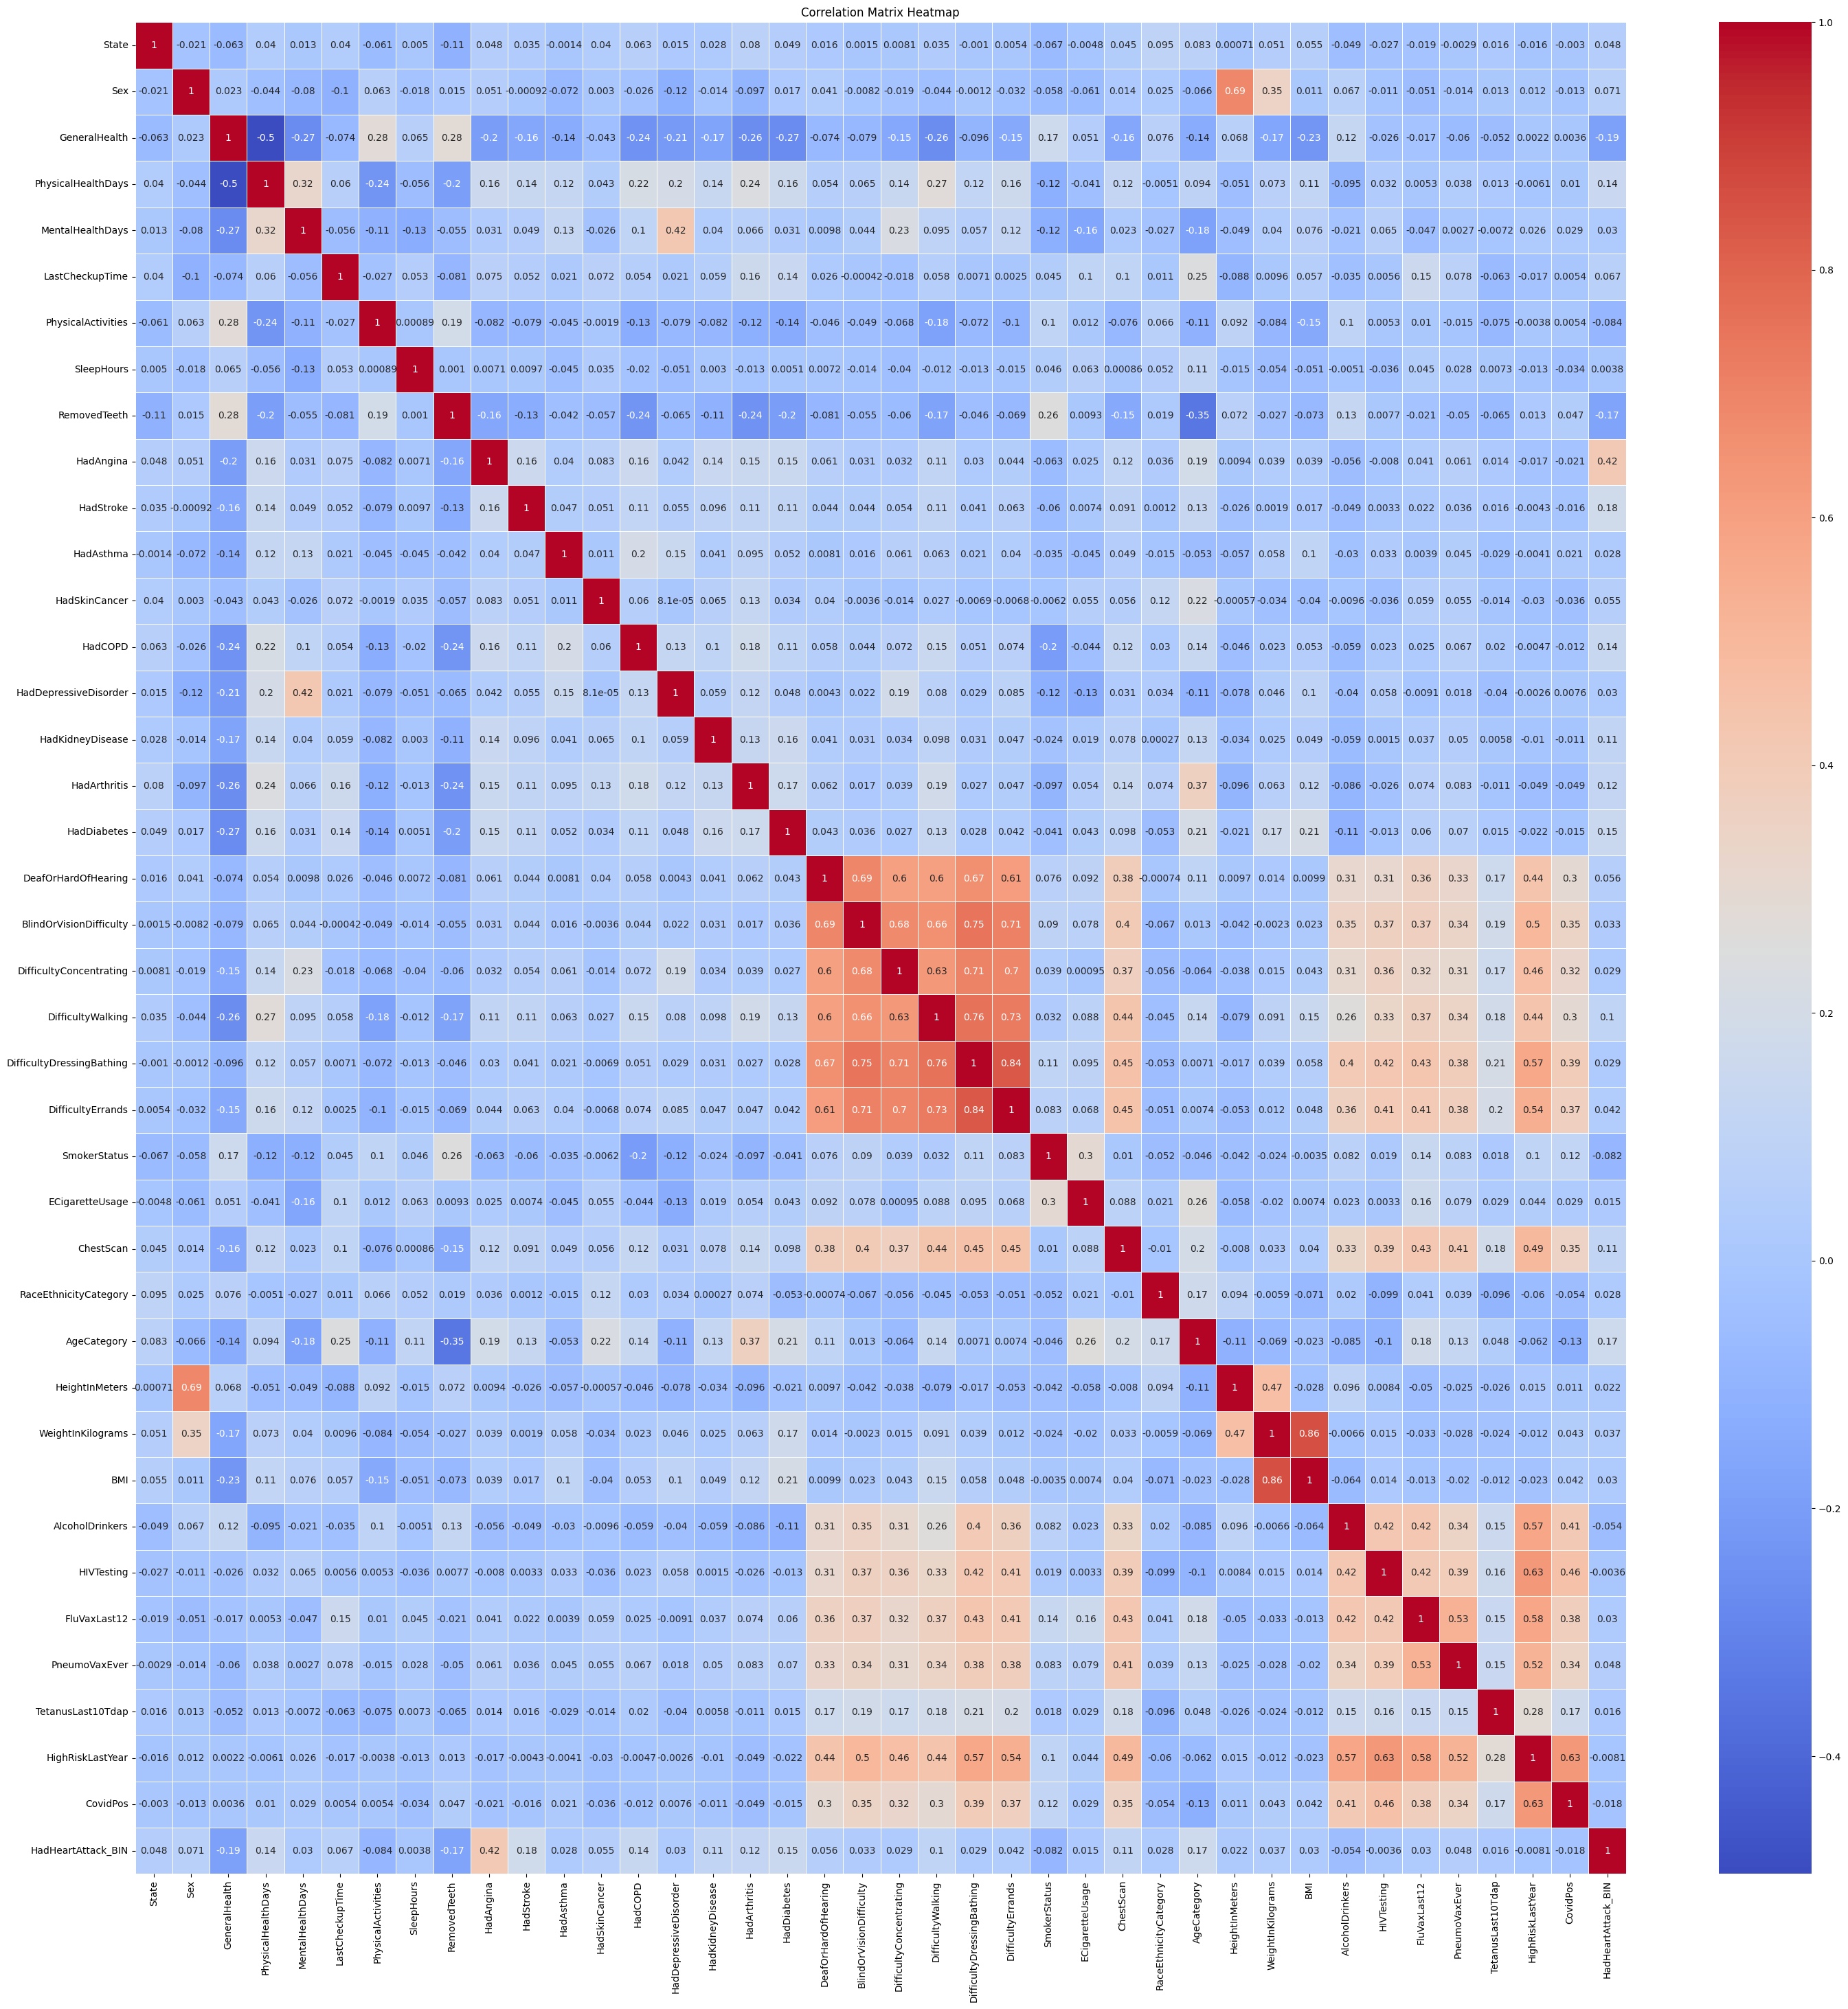

In [67]:
import seaborn as sns

correlation_matrix = df.corr()

plt.figure(figsize=(35, 35))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [68]:
correlation_with_target = correlation_matrix['HadHeartAttack_BIN'].drop('HadHeartAttack_BIN')


sorted_correlation = correlation_with_target.abs().sort_values(ascending=False)


print("Features sorted by their correlation with HadHeartAttack_BIN:")
print(sorted_correlation)

Features sorted by their correlation with HadHeartAttack_BIN:
HadAngina                    0.415863
GeneralHealth                0.187264
HadStroke                    0.180887
RemovedTeeth                 0.171981
AgeCategory                  0.170662
HadDiabetes                  0.149799
PhysicalHealthDays           0.142547
HadCOPD                      0.137120
HadArthritis                 0.121199
HadKidneyDisease             0.110346
ChestScan                    0.108992
DifficultyWalking            0.102983
PhysicalActivities           0.084468
SmokerStatus                 0.082375
Sex                          0.071067
LastCheckupTime              0.067453
DeafOrHardOfHearing          0.056272
HadSkinCancer                0.054659
AlcoholDrinkers              0.053572
PneumoVaxEver                0.048457
State                        0.048358
DifficultyErrands            0.042182
WeightInKilograms            0.037354
BlindOrVisionDifficulty      0.033170
FluVaxLast12              

#By examining the thermal correlation matrix, we can conclude that we can remove the following parameters that have too little effect on our target variable and will only overload our model

In [69]:
columns_to_keep = [
    'HadAngina',
    'GeneralHealth',
    'HadStroke',
    'RemovedTeeth',
    'AgeCategory',
    'HadDiabetes',
    'PhysicalHealthDays',
    'HadCOPD',
    'HadArthritis',
    'HadKidneyDisease',
    'ChestScan',
    'DifficultyWalking',
    'PhysicalActivities',
    'SmokerStatus',
    'Sex',
    'LastCheckupTime',
    'DeafOrHardOfHearing',
    'HadSkinCancer',
    'AlcoholDrinkers',
    'PneumoVaxEver',
    'State'
]


new_df = df[columns_to_keep]

In [70]:
new_df

,HadAngina,GeneralHealth,HadStroke,RemovedTeeth,AgeCategory,HadDiabetes,PhysicalHealthDays,HadCOPD,HadArthritis,HadKidneyDisease,...,DifficultyWalking,PhysicalActivities,SmokerStatus,Sex,LastCheckupTime,DeafOrHardOfHearing,HadSkinCancer,AlcoholDrinkers,PneumoVaxEver,State
0,0,4,0,2,12,1.0,0.0,0,0,0,...,0,0,3.0,0,3,0,0,0,0,2.244880
1,0,5,0,2,12,0.0,0.0,0,0,0,...,0,0,3.0,0,2,0,1,0,0,2.244880
2,0,4,0,2,7,0.0,2.0,0,0,0,...,0,1,3.0,0,3,0,1,0,0,2.244880
3,0,5,0,2,13,0.0,0.0,0,1,0,...,0,1,1.0,0,3,0,0,0,1,2.244880
4,0,2,0,2,4,0.0,2.0,0,0,0,...,0,1,3.0,0,3,0,0,1,1,2.244880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
442062,0,3,0,3,0,0.0,0.0,0,0,0,...,0,1,3.0,0,2,0,0,2,0,1.276018
442063,0,5,0,3,6,0.0,2.0,0,0,0,...,0,1,3.0,0,3,0,0,0,0,1.276018
442064,0,1,0,2,9,0.0,30.0,0,0,0,...,0,0,0.5,0,1,0,0,2,0,1.276018
442065,0,4,0,3,10,0.0,0.0,0,0,0,...,0,0,3.0,1,3,0,0,0,1,1.276018


In [73]:
!pip install catboost

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [89]:

from sklearn.model_selection import GridSearchCV

X = df.drop('HadHeartAttack_BIN', axis=1)
y = df['HadHeartAttack_BIN']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [85]:
nan_counts = df.isna().sum()
print(nan_counts)

State                            0
Sex                              0
GeneralHealth                    0
PhysicalHealthDays           10597
MentalHealthDays              8792
LastCheckupTime                  0
PhysicalActivities               0
SleepHours                    5196
RemovedTeeth                     0
HadAngina                        0
HadStroke                        0
HadAsthma                        0
HadSkinCancer                    0
HadCOPD                          0
HadDepressiveDisorder            0
HadKidneyDisease                 0
HadArthritis                     0
HadDiabetes                      0
DeafOrHardOfHearing              0
BlindOrVisionDifficulty          0
DifficultyConcentrating          0
DifficultyWalking                0
DifficultyDressingBathing        0
DifficultyErrands                0
SmokerStatus                     0
ECigaretteUsage                  0
ChestScan                        0
RaceEthnicityCategory            0
AgeCategory         

###We see that there are very few Nan values ​​and the only remaining ones are in the columns where there are binary answers. So we can't fill them out. Accordingly, they need to be removed, however, there are few of them, therefore, we can do it

In [86]:
df= df.dropna()

#Let's move on to training machine learning models

#1.CatBoostClassifier

In [81]:

# Инициализация модели CatBoostClassifier
model = CatBoostClassifier(silent=True)

# Определение сетки параметров для grid search
param_grid = {
    'iterations': [100, 200],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [ 7, 9]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_

best_score = grid_search.best_score_

print("Best parameters found: ", best_params)
print("Best accuracy found: ", best_score)

'''

Best parameters found:  {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 9, 'learning_rate': 0.1}
Best accuracy found:  0.947391934487829
'''



Best parameters found:  {'depth': 6, 'iterations': 100, 'l2_leaf_reg': 9, 'learning_rate': 0.1}
Best accuracy found:  0.947391934487829


CatBoost Accuracy on test data: 0.9469865775372699
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     71075
           1       0.60      0.23      0.33      4321

    accuracy                           0.95     75396
   macro avg       0.78      0.61      0.65     75396
weighted avg       0.93      0.95      0.94     75396



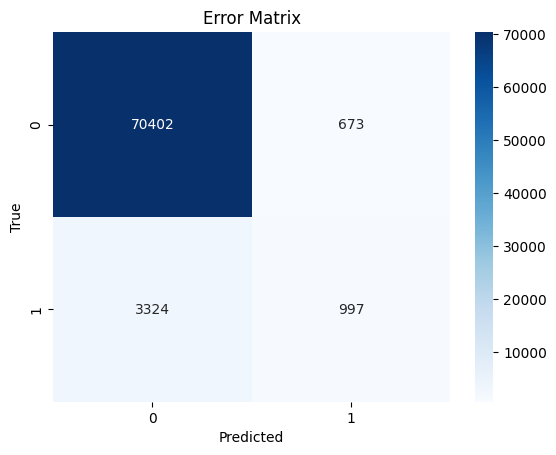

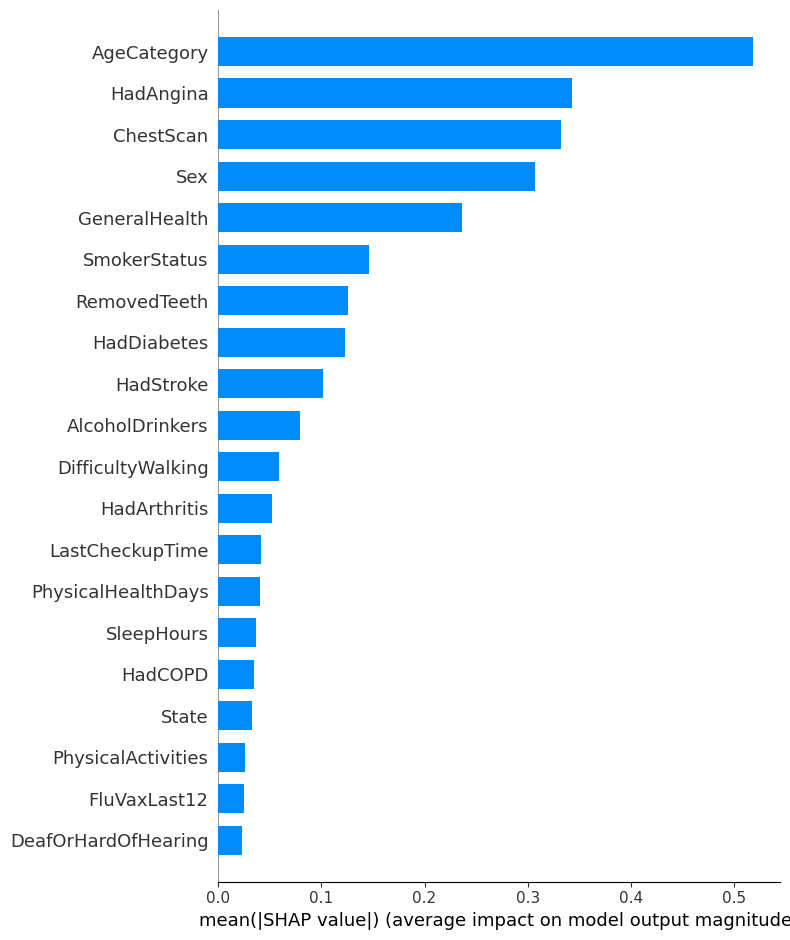

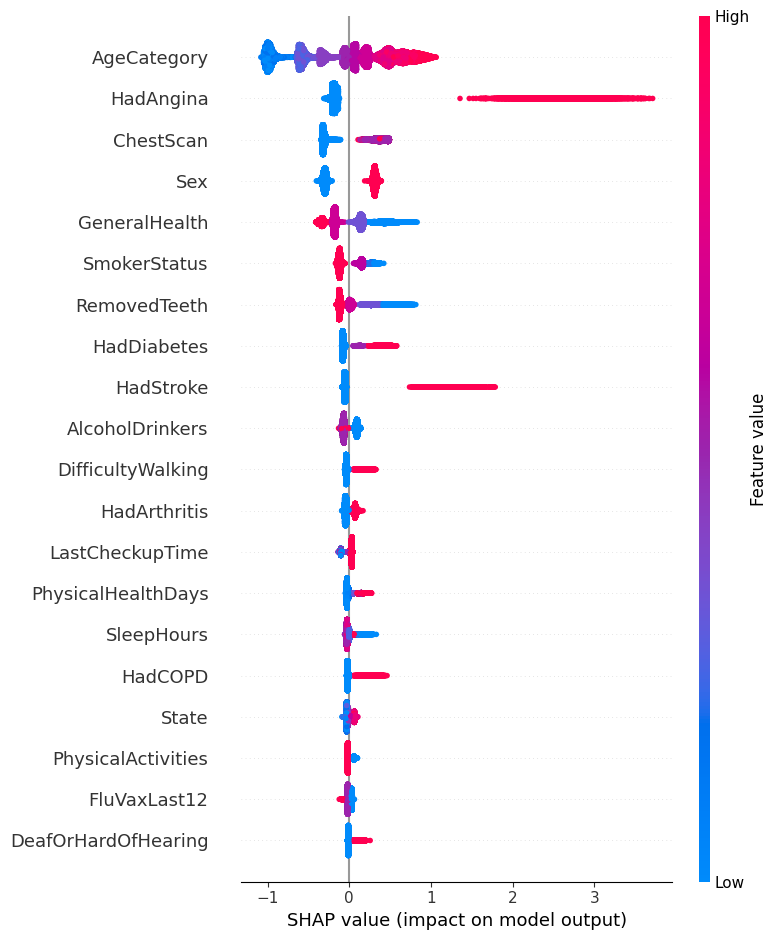

Количество ошибок: 3997
Примеры ошибочных предсказаний:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
326157  1.902753    1              4                 0.0               0.0   
394021  1.523398    1              4                 0.0               0.0   
320590  1.844774    1              4                 0.0               0.0   
208707  1.739618    0              1                14.0              30.0   
10397   2.259523    1              3                 3.0               8.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
326157                3                   1         8.0             3   
394021                3                   0         9.0             2   
320590                3                   0         6.0             1   
208707                1                   0         6.0             1   
10397                 2                   1         7.0             1   

        HadAngina  ...  HeightInMete

In [98]:
model_cat = CatBoostClassifier(depth=6, iterations=100, l2_leaf_reg=9, learning_rate=0.1, silent=True)
model_cat.fit(X_train, y_train)

y_pred_cat = model_cat.predict(X_test)
print(f'CatBoost Accuracy on test data: {accuracy_score(y_test, y_pred_cat)}')
print(classification_report(y_test, y_pred_cat))

conf_matrix = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

explainer = shap.TreeExplainer(model_cat)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

# Анализ ошибок
errors = X_test[(y_pred_cat != y_test)]
print(f'Количество ошибок: {len(errors)}')
print("Примеры ошибочных предсказаний:")
print(errors.head())

#2. DummyClissifer

In [101]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_y_pred = dummy_clf.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_y_pred)
print("Accuracy of sklearn DummyClassifier: ", dummy_accuracy)






Accuracy of sklearn DummyClassifier:  0.9426892673351371


Dummy Accuracy on test data: 0.9426892673351371


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.94      1.00      0.97     71075
           1       0.00      0.00      0.00      4321

    accuracy                           0.94     75396
   macro avg       0.47      0.50      0.49     75396
weighted avg       0.89      0.94      0.91     75396



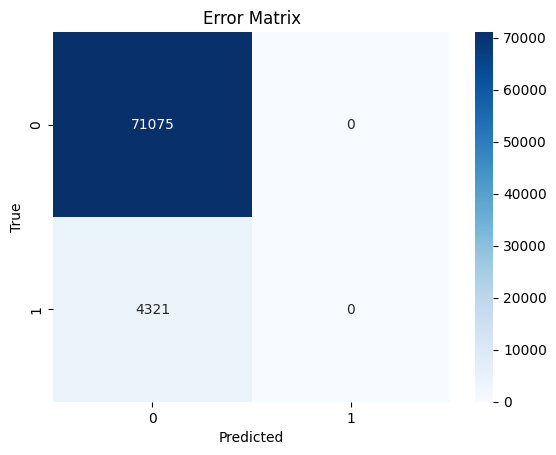

Number of mistakes: 4321
Examples of erroneous predictions:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
394021  1.523398    1              4                 0.0               0.0   
208707  1.739618    0              1                14.0              30.0   
10397   2.259523    1              3                 3.0               8.0   
54004   1.470192    1              4                 1.0               0.0   
207046  1.448515    1              3                 2.0               0.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
394021                3                   0         9.0             2   
208707                1                   0         6.0             1   
10397                 2                   1         7.0             1   
54004                 3                   1         7.0             1   
207046                3                   0         8.0             3   

        HadAngina  ...  HeightIn

In [103]:

print(f'Dummy Accuracy on test data: {accuracy_score(y_test, dummy_y_pred)}')
print(classification_report(y_test, dummy_y_pred))

conf_matrix = confusion_matrix(y_test, dummy_y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()


# Анализ ошибок
errors = X_test[(dummy_y_pred != y_test)]
print(f'Number of mistakes: {len(errors)}')
print("Examples of erroneous predictions:")
print(errors.head())

#3. Logistic Regression

In [ ]:

param_grid_l_r = {
    'C': [0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear']
}

grid_search_l_r = GridSearchCV(LogisticRegression(), param_grid_l_r, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_l_r.fit(X_train, y_train)

print(f'Best params: {grid_search_l_r.best_params_}')
print(f'Best cross-validation accuracy: {grid_search_l_r.best_score_}')

best_model_l_r = grid_search_l_r.best_estimator_

'''
Запускаю сразу в нескольких блокнотах, результат:

Best params: {'C': 0.1, 'solver': 'liblinear'}
Best cross-validation accuracy: 0.9450096160222827
'''



In [90]:
best_params_l_r = {'C': 0.1, 'solver': 'liblinear'}
model_l_r = LogisticRegression(**best_params_l_r )
model_l_r.fit(X_train, y_train)

LogisticRegression(C=0.1, solver='liblinear')

Accuracy on test data: 0.9448511857392965
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     71075
           1       0.55      0.20      0.30      4321

    accuracy                           0.94     75396
   macro avg       0.75      0.60      0.63     75396
weighted avg       0.93      0.94      0.93     75396



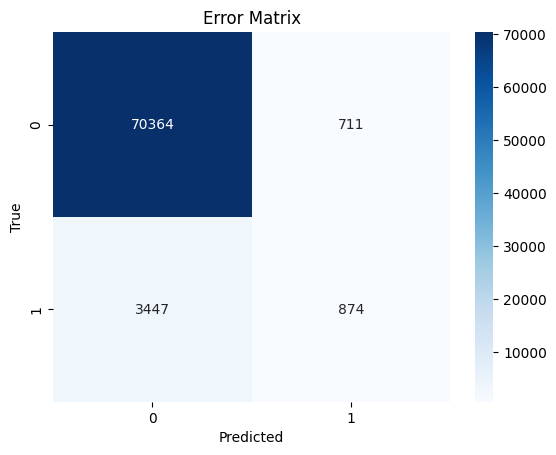

In [91]:
y_pred_l_r = model_l_r.predict(X_test)
print(f'Accuracy on test data: {accuracy_score(y_test, y_pred_l_r)}')
print(classification_report(y_test, y_pred_l_r))

conf_matrix = confusion_matrix(y_test, y_pred_l_r)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

  Using cached shap-0.46.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl (540 kB)
  Using cached slicer-0.0.8-py3-none-any.whl (15 kB)


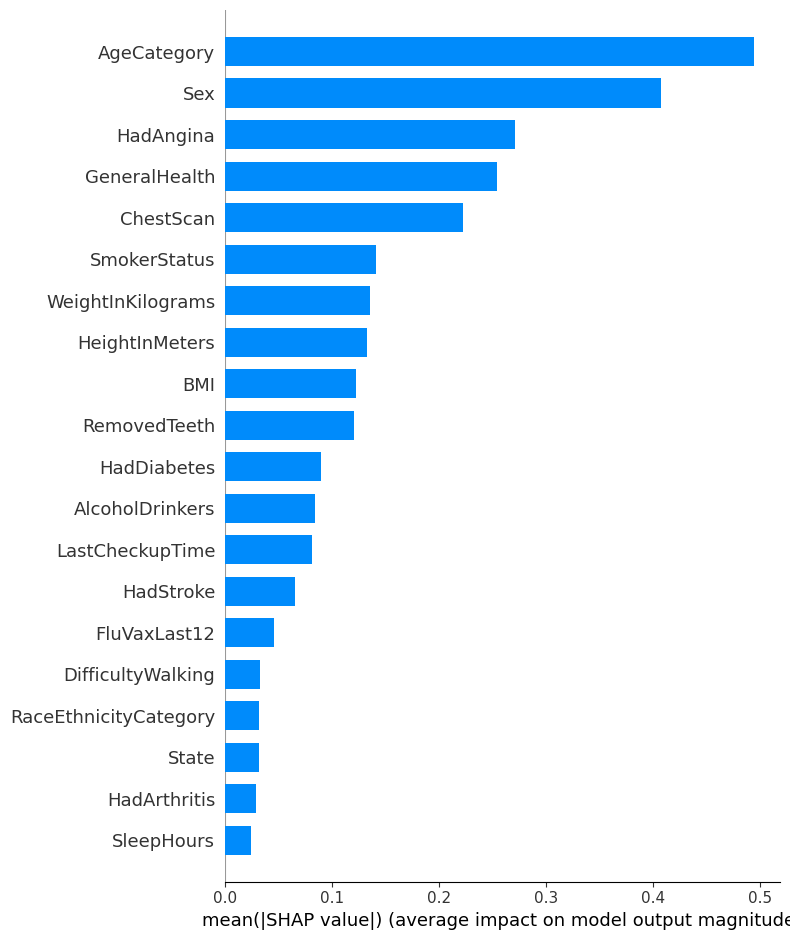

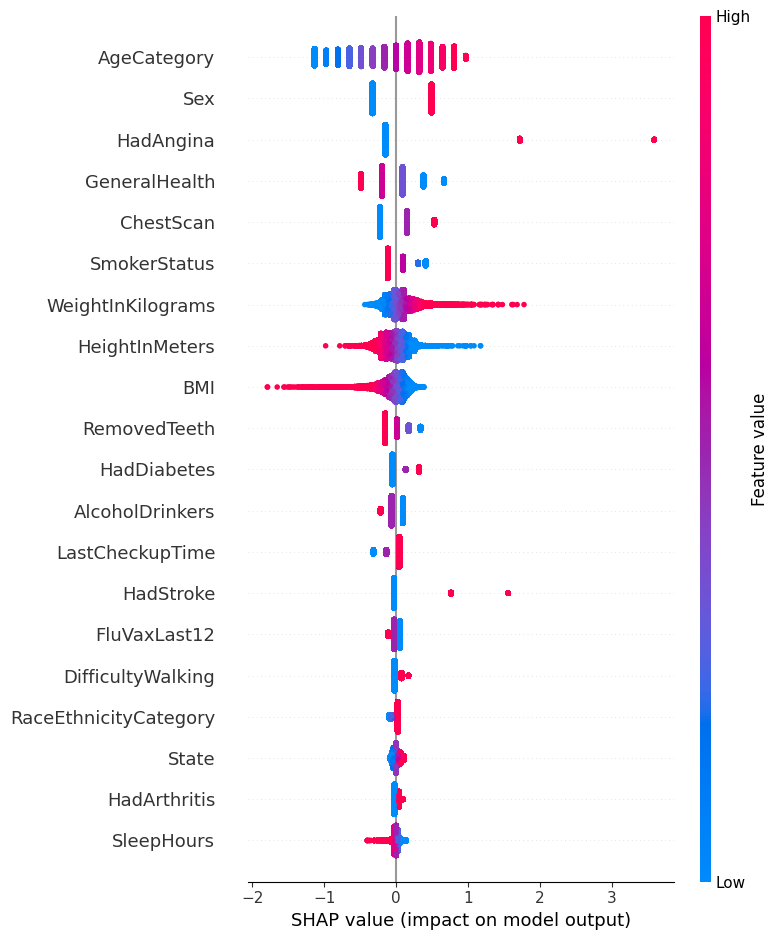

In [94]:
!pip install shap
import shap

explainer = shap.Explainer(model_l_r, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")
shap.summary_plot(shap_values, X_test)


#4.LightGBM

In [95]:
from lightgbm import LGBMClassifier


param_grid_LGBM = {
    'n_estimators': [ 100, 200],
    'learning_rate': [ 0.1, 0.2],
    'max_depth': [ 6, 8]
}

# Инициализация и выполнение GridSearchCV
grid_search = GridSearchCV(LGBMClassifier(), param_grid_LGBM, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


'''
lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=6)
lgbm_model.fit(X_train, y_train)
'''
best_model = grid_search.best_estimator_


y_pred = best_model.predict(X_test)
print(f'LightGBM Accuracy on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 17080, number of negative: 284500
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.125595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 851
[LightGBM] [Info] Number of data points in the train set: 301580, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.056635 -> initscore=-2.812825
[LightGBM] [Info] Start training from score -2.812825
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Accuracy m

In [107]:
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


LightGBM Accuracy on test data: 0.9471987903867579
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     71075
           1       0.60      0.25      0.35      4321

    accuracy                           0.95     75396
   macro avg       0.78      0.62      0.66     75396
weighted avg       0.94      0.95      0.94     75396



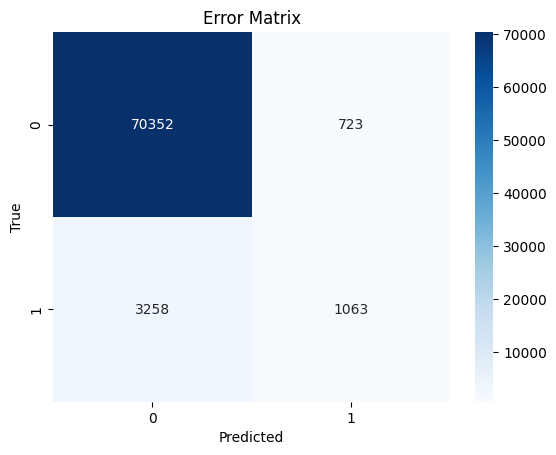

/usr/local/lib/python3.10/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


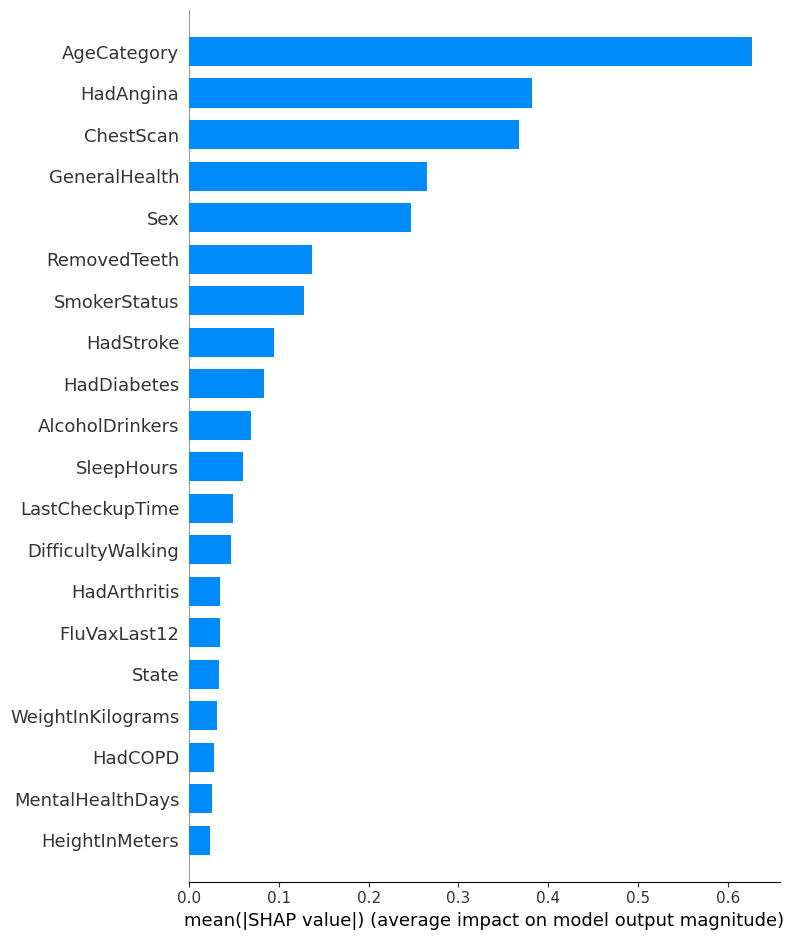

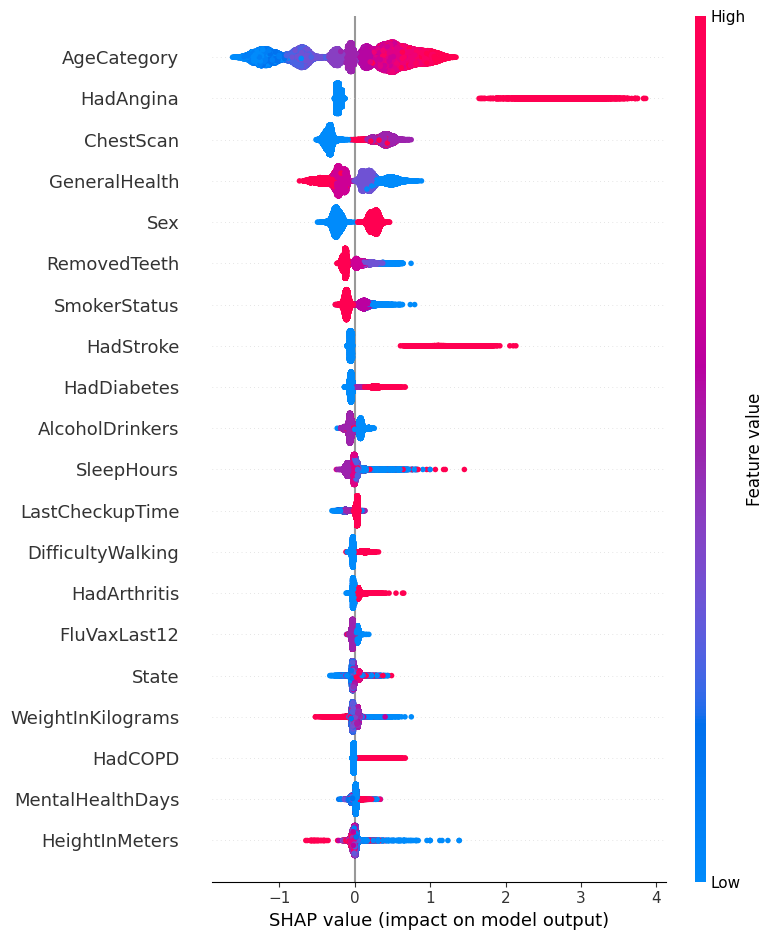

Количество ошибок: 3981
Примеры ошибочных предсказаний:
           State  Sex  GeneralHealth  PhysicalHealthDays  MentalHealthDays  \
326157  1.902753    1              4                 0.0               0.0   
394021  1.523398    1              4                 0.0               0.0   
320590  1.844774    1              4                 0.0               0.0   
10397   2.259523    1              3                 3.0               8.0   
54004   1.470192    1              4                 1.0               0.0   

        LastCheckupTime  PhysicalActivities  SleepHours  RemovedTeeth  \
326157                3                   1         8.0             3   
394021                3                   0         9.0             2   
320590                3                   0         6.0             1   
10397                 2                   1         7.0             1   
54004                 3                   1         7.0             1   

        HadAngina  ...  HeightInMete

In [104]:

print(f'LightGBM Accuracy on test data: {accuracy_score(y_test, y_pred)}')
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Error Matrix')
plt.show()

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

# Анализ ошибок
errors = X_test[(y_pred != y_test)]
print(f'Количество ошибок: {len(errors)}')
print("Примеры ошибочных предсказаний:")
print(errors.head())

#Learning curve

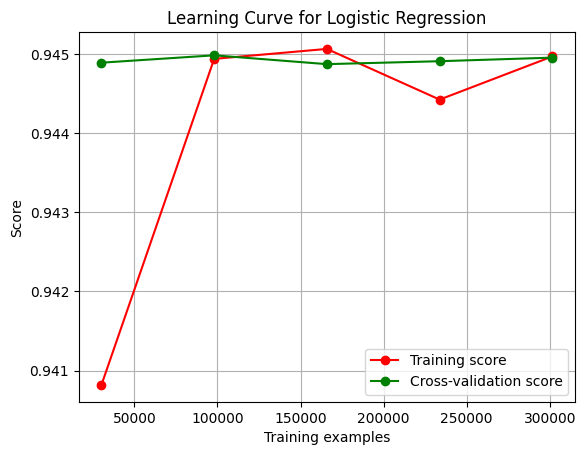

0:	learn: 0.5457392	total: 10ms	remaining: 992ms
1:	learn: 0.4393375	total: 20.9ms	remaining: 1.02s
2:	learn: 0.3620795	total: 31.7ms	remaining: 1.02s
3:	learn: 0.3065256	total: 57.2ms	remaining: 1.37s
4:	learn: 0.2680413	total: 73.1ms	remaining: 1.39s
5:	learn: 0.2398434	total: 82.9ms	remaining: 1.3s
6:	learn: 0.2197298	total: 95.3ms	remaining: 1.27s
7:	learn: 0.2006111	total: 107ms	remaining: 1.23s
8:	learn: 0.1918000	total: 118ms	remaining: 1.19s
9:	learn: 0.1827240	total: 129ms	remaining: 1.16s
10:	learn: 0.1754377	total: 142ms	remaining: 1.15s
11:	learn: 0.1697174	total: 154ms	remaining: 1.13s
12:	learn: 0.1655300	total: 165ms	remaining: 1.1s
13:	learn: 0.1618281	total: 178ms	remaining: 1.09s
14:	learn: 0.1598628	total: 190ms	remaining: 1.07s
15:	learn: 0.1577349	total: 199ms	remaining: 1.04s
16:	learn: 0.1548491	total: 214ms	remaining: 1.04s
17:	learn: 0.1534126	total: 225ms	remaining: 1.02s
18:	learn: 0.1518438	total: 237ms	remaining: 1.01s
19:	learn: 0.1505447	total: 248ms	rema

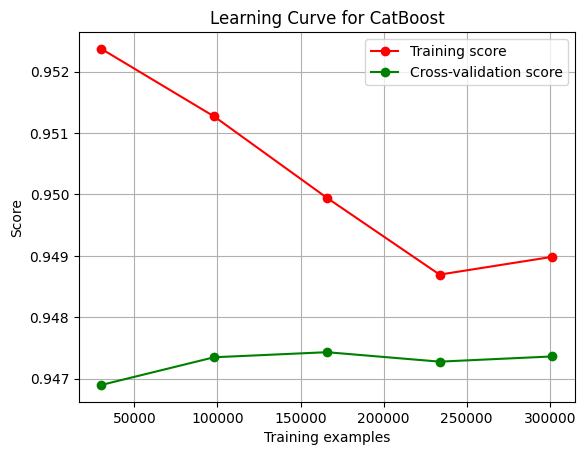

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Number of positive: 1710, number of negative: 28448
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 764
[LightGBM] [Info] Number of data points in the train set: 30158, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.056701 -> initscore=-2.811584
[LightGBM] [Info] Start training from score -2.811584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

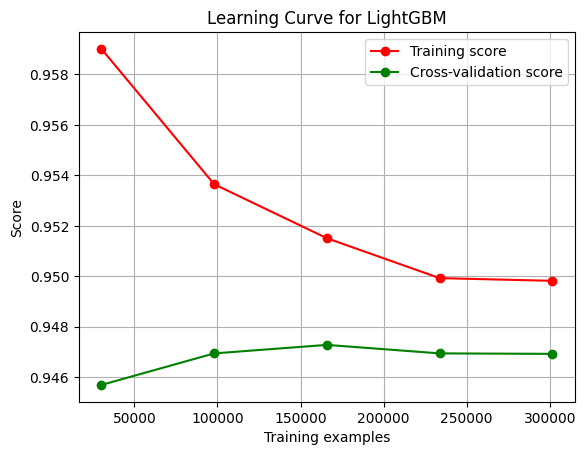

In [108]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

plot_learning_curve(LogisticRegression(**{'C': 0.1, 'solver': 'liblinear'}), "Learning Curve for Logistic Regression", X, y, cv=5)
plt.show()

plot_learning_curve(CatBoostClassifier(**{'depth': 6, 'iterations': 100, 'l2_leaf_reg': 9, 'learning_rate': 0.1}), "Learning Curve for CatBoost", X, y, cv=5)
plt.show()

plot_learning_curve(LGBMClassifier(**{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}), "Learning Curve for LightGBM", X, y, cv=5)
plt.show()


#And now about Fully Connected Neural Network (FCNN)

#Number of layers and neurons in each package:

###1. The input layer will consist of a number of neurons equal to the number of features (in this case 21 (21 parametrs)).
###2. For hidden layers, I will choose 3 layers with gradually decreasing number of neurons:
### 1. 128 neurons(I chose the number of neurons large enough so that the network could learn complex dependencies between features.) with ReLU activation function.
###2. 64 neurons(It serves to further extract the feature hierarchy, as well as to reduce the dimensionality of the data before the final layers. This is the reason why there are already fewer neurons in it than in the previous layer) with ReLU activation function.
###3. 32 neurons(I reduce the number of neurons as I move through the network and this greatly helps the network focus on higher-level features) with ReLU activation function. This allows models to learn complex patterns at a high level of abstraction in early layers and refine them in simpler layers.

###I chose ReLU as the activation function for the hidden layers. The advantage of ReLU is that it promotes sparse activations, which speeds up training and improves the model's generalization ability. ReLU also helps avoid the problem of decaying gradients that is common with saturated activation functions.


###3.The output layer will consist of a single neuron with sigmoidal reduced efficiency for binary class prediction.
###For the output layer, I chose a sigmoid activation function, which transforms the neuron's output into an interval between 0 and 1, interpreted as guards to the positive class. Therefore, it is perfect for our task, the binary classification problem.

###Adam was selected as the optimizer with the learning_rate=0.001 parameter.


###Epochs and batch size are selected as standard: 50 epochs and batch size 32.

In [ ]:
!pip install tensorflow


from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Масштабируем данные
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Построим модель
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Компилируем модель
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Обучим модель
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Оценим модель
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy}')


'''
Несколько моделей я запускала на нескольких блокнотах
Результат:






Requirement already satisfied: tensorflow in /usr/local/lib/python3.10/dist-packages (2.15.0)
Requirement already satisfied: absl-py>=1.0.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.4.0)
Requirement already satisfied: astunparse>=1.6.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.6.3)
Requirement already satisfied: flatbuffers>=23.5.26 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (24.3.25)
Requirement already satisfied: gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (0.6.0)
Requirement already satisfied: google-pasta>=0.1.1 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (0.2.0)
Requirement already satisfied: h5py>=2.9.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (3.9.0)
Requirement already satisfied: libclang>=13.0.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (18.1.1)
Requirement already satisfied: ml-dtypes~=0.2.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (0.2.0)
Requirement already satisfied: numpy<2.0.0,>=1.23.5 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.25.2)
Requirement already satisfied: opt-einsum>=2.3.2 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (3.3.0)
Requirement already satisfied: packaging in /usr/local/lib/python3.10/dist-packages (from tensorflow) (24.1)
Requirement already satisfied: protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (3.20.3)
Requirement already satisfied: setuptools in /usr/local/lib/python3.10/dist-packages (from tensorflow) (67.7.2)
Requirement already satisfied: six>=1.12.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.16.0)
Requirement already satisfied: termcolor>=1.1.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (2.4.0)
Requirement already satisfied: typing-extensions>=3.6.6 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (4.12.2)
Requirement already satisfied: wrapt<1.15,>=1.11.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.14.1)
Requirement already satisfied: tensorflow-io-gcs-filesystem>=0.23.1 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (0.37.0)
Requirement already satisfied: grpcio<2.0,>=1.24.3 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (1.64.1)
Requirement already satisfied: tensorboard<2.16,>=2.15 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (2.15.2)
Requirement already satisfied: tensorflow-estimator<2.16,>=2.15.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (2.15.0)
Requirement already satisfied: keras<2.16,>=2.15.0 in /usr/local/lib/python3.10/dist-packages (from tensorflow) (2.15.0)
Requirement already satisfied: wheel<1.0,>=0.23.0 in /usr/local/lib/python3.10/dist-packages (from astunparse>=1.6.0->tensorflow) (0.43.0)
Requirement already satisfied: google-auth<3,>=1.6.3 in /usr/local/lib/python3.10/dist-packages (from tensorboard<2.16,>=2.15->tensorflow) (2.27.0)
Requirement already satisfied: google-auth-oauthlib<2,>=0.5 in /usr/local/lib/python3.10/dist-packages (from tensorboard<2.16,>=2.15->tensorflow) (1.2.0)
Requirement already satisfied: markdown>=2.6.8 in /usr/local/lib/python3.10/dist-packages (from tensorboard<2.16,>=2.15->tensorflow) (3.6)
Requirement already satisfied: requests<3,>=2.21.0 in /usr/local/lib/python3.10/dist-packages (from tensorboard<2.16,>=2.15->tensorflow) (2.31.0)
Requirement already satisfied: tensorboard-data-server<0.8.0,>=0.7.0 in /usr/local/lib/python3.10/dist-packages (from tensorboard<2.16,>=2.15->tensorflow) (0.7.2)
Requirement already satisfied: werkzeug>=1.0.1 in /usr/local/lib/python3.10/dist-packages (from tensorboard<2.16,>=2.15->tensorflow) (3.0.3)
Requirement already satisfied: cachetools<6.0,>=2.0.0 in /usr/local/lib/python3.10/dist-packages (from google-auth<3,>=1.6.3->tensorboard<2.16,>=2.15->tensorflow) (5.3.3)
Requirement already satisfied: pyasn1-modules>=0.2.1 in /usr/local/lib/python3.10/dist-packages (from google-auth<3,>=1.6.3->tensorboard<2.16,>=2.15->tensorflow) (0.4.0)
Requirement already satisfied: rsa<5,>=3.1.4 in /usr/local/lib/python3.10/dist-packages (from google-auth<3,>=1.6.3->tensorboard<2.16,>=2.15->tensorflow) (4.9)
Requirement already satisfied: requests-oauthlib>=0.7.0 in /usr/local/lib/python3.10/dist-packages (from google-auth-oauthlib<2,>=0.5->tensorboard<2.16,>=2.15->tensorflow) (1.3.1)
Requirement already satisfied: charset-normalizer<4,>=2 in /usr/local/lib/python3.10/dist-packages (from requests<3,>=2.21.0->tensorboard<2.16,>=2.15->tensorflow) (3.3.2)
Requirement already satisfied: idna<4,>=2.5 in /usr/local/lib/python3.10/dist-packages (from requests<3,>=2.21.0->tensorboard<2.16,>=2.15->tensorflow) (3.7)
Requirement already satisfied: urllib3<3,>=1.21.1 in /usr/local/lib/python3.10/dist-packages (from requests<3,>=2.21.0->tensorboard<2.16,>=2.15->tensorflow) (2.0.7)
Requirement already satisfied: certifi>=2017.4.17 in /usr/local/lib/python3.10/dist-packages (from requests<3,>=2.21.0->tensorboard<2.16,>=2.15->tensorflow) (2024.6.2)
Requirement already satisfied: MarkupSafe>=2.1.1 in /usr/local/lib/python3.10/dist-packages (from werkzeug>=1.0.1->tensorboard<2.16,>=2.15->tensorflow) (2.1.5)
Requirement already satisfied: pyasn1<0.7.0,>=0.4.6 in /usr/local/lib/python3.10/dist-packages (from pyasn1-modules>=0.2.1->google-auth<3,>=1.6.3->tensorboard<2.16,>=2.15->tensorflow) (0.6.0)
Requirement already satisfied: oauthlib>=3.0.0 in /usr/local/lib/python3.10/dist-packages (from requests-oauthlib>=0.7.0->google-auth-oauthlib<2,>=0.5->tensorboard<2.16,>=2.15->tensorflow) (3.2.2)
Epoch 1/50
9425/9425 [==============================] - 30s 3ms/step - loss: 0.1514 - accuracy: 0.9457 - val_loss: 0.1494 - val_accuracy: 0.9464
Epoch 2/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1473 - accuracy: 0.9473 - val_loss: 0.1493 - val_accuracy: 0.9461
Epoch 3/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1464 - accuracy: 0.9476 - val_loss: 0.1490 - val_accuracy: 0.9461
Epoch 4/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1457 - accuracy: 0.9480 - val_loss: 0.1491 - val_accuracy: 0.9467
Epoch 5/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1453 - accuracy: 0.9484 - val_loss: 0.1497 - val_accuracy: 0.9462
Epoch 6/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1446 - accuracy: 0.9486 - val_loss: 0.1487 - val_accuracy: 0.9463
Epoch 7/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1439 - accuracy: 0.9490 - val_loss: 0.1495 - val_accuracy: 0.9460
Epoch 8/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1432 - accuracy: 0.9492 - val_loss: 0.1504 - val_accuracy: 0.9459
Epoch 9/50
9425/9425 [==============================] - 23s 2ms/step - loss: 0.1423 - accuracy: 0.9501 - val_loss: 0.1500 - val_accuracy: 0.9455
Epoch 10/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1418 - accuracy: 0.9501 - val_loss: 0.1512 - val_accuracy: 0.9457
Epoch 11/50
9425/9425 [==============================] - 22s 2ms/step - loss: 0.1409 - accuracy: 0.9504 - val_loss: 0.1517 - val_accuracy: 0.9456
Epoch 12/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1398 - accuracy: 0.9509 - val_loss: 0.1527 - val_accuracy: 0.9450
Epoch 13/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1390 - accuracy: 0.9514 - val_loss: 0.1532 - val_accuracy: 0.9450
Epoch 14/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1380 - accuracy: 0.9518 - val_loss: 0.1544 - val_accuracy: 0.9445
Epoch 15/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1372 - accuracy: 0.9520 - val_loss: 0.1541 - val_accuracy: 0.9448
Epoch 16/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1363 - accuracy: 0.9527 - val_loss: 0.1572 - val_accuracy: 0.9447
Epoch 17/50
9425/9425 [==============================] - 23s 2ms/step - loss: 0.1355 - accuracy: 0.9527 - val_loss: 0.1589 - val_accuracy: 0.9447
Epoch 18/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1347 - accuracy: 0.9531 - val_loss: 0.1583 - val_accuracy: 0.9441
Epoch 19/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1337 - accuracy: 0.9534 - val_loss: 0.1591 - val_accuracy: 0.9437
Epoch 20/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1329 - accuracy: 0.9539 - val_loss: 0.1636 - val_accuracy: 0.9445
Epoch 21/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1321 - accuracy: 0.9539 - val_loss: 0.1623 - val_accuracy: 0.9436
Epoch 22/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1313 - accuracy: 0.9546 - val_loss: 0.1651 - val_accuracy: 0.9432
Epoch 23/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1305 - accuracy: 0.9549 - val_loss: 0.1689 - val_accuracy: 0.9436
Epoch 24/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1299 - accuracy: 0.9549 - val_loss: 0.1685 - val_accuracy: 0.9440
Epoch 25/50
9425/9425 [==============================] - 28s 3ms/step - loss: 0.1291 - accuracy: 0.9550 - val_loss: 0.1671 - val_accuracy: 0.9434
Epoch 26/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1283 - accuracy: 0.9554 - val_loss: 0.1678 - val_accuracy: 0.9437
Epoch 27/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1280 - accuracy: 0.9557 - val_loss: 0.1692 - val_accuracy: 0.9439
Epoch 28/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1269 - accuracy: 0.9562 - val_loss: 0.1707 - val_accuracy: 0.9436
Epoch 29/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1267 - accuracy: 0.9560 - val_loss: 0.1778 - val_accuracy: 0.9433
Epoch 30/50
9425/9425 [==============================] - 23s 2ms/step - loss: 0.1258 - accuracy: 0.9564 - val_loss: 0.1746 - val_accuracy: 0.9427
Epoch 31/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1255 - accuracy: 0.9564 - val_loss: 0.1712 - val_accuracy: 0.9435
Epoch 32/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1249 - accuracy: 0.9566 - val_loss: 0.1752 - val_accuracy: 0.9435
Epoch 33/50
9425/9425 [==============================] - 22s 2ms/step - loss: 0.1242 - accuracy: 0.9569 - val_loss: 0.1821 - val_accuracy: 0.9432
Epoch 34/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1238 - accuracy: 0.9569 - val_loss: 0.1829 - val_accuracy: 0.9439
Epoch 35/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1234 - accuracy: 0.9569 - val_loss: 0.1791 - val_accuracy: 0.9439
Epoch 36/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1227 - accuracy: 0.9573 - val_loss: 0.1887 - val_accuracy: 0.9439
Epoch 37/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1224 - accuracy: 0.9574 - val_loss: 0.1858 - val_accuracy: 0.9431
Epoch 38/50
9425/9425 [==============================] - 26s 3ms/step - loss: 0.1219 - accuracy: 0.9577 - val_loss: 0.1851 - val_accuracy: 0.9435
Epoch 39/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1213 - accuracy: 0.9576 - val_loss: 0.1877 - val_accuracy: 0.9433
Epoch 40/50
9425/9425 [==============================] - 23s 2ms/step - loss: 0.1207 - accuracy: 0.9579 - val_loss: 0.1858 - val_accuracy: 0.9434
Epoch 41/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1202 - accuracy: 0.9579 - val_loss: 0.1928 - val_accuracy: 0.9433
Epoch 42/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1199 - accuracy: 0.9581 - val_loss: 0.1986 - val_accuracy: 0.9438
Epoch 43/50
9425/9425 [==============================] - 30s 3ms/step - loss: 0.1199 - accuracy: 0.9582 - val_loss: 0.1887 - val_accuracy: 0.9435
Epoch 44/50
9425/9425 [==============================] - 24s 3ms/step - loss: 0.1192 - accuracy: 0.9583 - val_loss: 0.1905 - val_accuracy: 0.9427
Epoch 45/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1186 - accuracy: 0.9584 - val_loss: 0.1969 - val_accuracy: 0.9430
Epoch 46/50
9425/9425 [==============================] - 23s 2ms/step - loss: 0.1185 - accuracy: 0.9586 - val_loss: 0.1964 - val_accuracy: 0.9432
Epoch 47/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1180 - accuracy: 0.9587 - val_loss: 0.2026 - val_accuracy: 0.9436
Epoch 48/50
9425/9425 [==============================] - 25s 3ms/step - loss: 0.1177 - accuracy: 0.9589 - val_loss: 0.2025 - val_accuracy: 0.9427
Epoch 49/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1175 - accuracy: 0.9591 - val_loss: 0.2035 - val_accuracy: 0.9439
Epoch 50/50
9425/9425 [==============================] - 27s 3ms/step - loss: 0.1173 - accuracy: 0.9590 - val_loss: 0.1998 - val_accuracy: 0.9427
2357/2357 [==============================] - 3s 1ms/step - loss: 0.1998 - accuracy: 0.9427
Test Accuracy: 0.9426627159118652

'''

#As a result we have:
#1. CatBoostClassifier Best accuracy found:  0.947391934487829
#2. LightGBM Accuracy on test data: 0.9471987903867579
#3. Accuracy of sklearn DummyClassifier:  0.9426892673351371
#4. Logistic Regression Best cross-validation accuracy: 0.9450096160222827
#5. Fully Connected Neural Network Test Accuracy: 0.9426627159118652

In [110]:
from sklearn.metrics import accuracy_score


accuracy_scores = {
    'CatBoostClassifier': 0.947391934487829,
    'LightGBM': 0.9471987903867579,
    'DummyClassifier': 0.9426892673351371,
    'Logistic Regression': 0.9450096160222827,
    'Fully Connected Neural Network': 0.9426627159118652
}


best_model_name = max(accuracy_scores, key=accuracy_scores.get)
best_accuracy = accuracy_scores[best_model_name]

print("Comparison of models based on accuracy on test data:")
for model_name, accuracy in accuracy_scores.items():
    print(f"{model_name}: Accuracy = {accuracy:.4f}")

print("\nBest Model:")
print(f"{best_model_name}: Best Accuracy = {best_accuracy:.4f}")


Comparison of models based on accuracy on test data:
CatBoostClassifier: Accuracy = 0.9474
LightGBM: Accuracy = 0.9472
DummyClassifier: Accuracy = 0.9427
Logistic Regression: Accuracy = 0.9450
Fully Connected Neural Network: Accuracy = 0.9427

Best Model:
CatBoostClassifier: Best Accuracy = 0.9474


#Conclusions:
#Among the models considered, CatBoostClassifier and LightGBM achieved the highest accuracy on the test data, with nearly identical performance.
#DummyClassifier and Fully Connected Neural Network showed slightly lower accuracy.